# Tuần 06 — Khái quát dữ liệu (2/7): Phân phối xác suất và biến ngẫu nhiên rời rạc

**UET.MAT1052 — Xác suất thống kê**  
ThS. Hoàng Hữu Bách — BM. Khoa học & Kỹ thuật tính toán - Khoa Công nghệ Thông tin, VNU-UET

Ở Tuần 05, ta tính xác suất của một biến cố: tổng hai xúc xắc bằng 7, một sản phẩm bị lỗi, hay một lượt quay roulette rơi vào ô đỏ. Tuần này, ta hỏi thêm: **nếu muốn biết toàn bộ các giá trị có thể xuất hiện, cùng xác suất của từng giá trị, cần mô tả thế nào?** Một bảng phân phối trả lời được câu hỏi đó. Từ bảng này, ta có thể tính cả xác suất tại một giá trị lẫn xác suất vượt qua một ngưỡng.

Notebook giữ 21 ví dụ của `Slides/week06.pdf`, cùng toàn bộ đề bài và lời giải. Slide tuần này dùng tên **Ví dụ 1–21**, không gắn mã `W06-...` hay mức độ; vì vậy các tên được giữ nguyên. Mục quy tắc đếm và roulette bổ sung theo đề cương và STAT 20, được ghi rõ khi xuất hiện. Python dùng Plotly cho hình có tham số để thay đổi và Matplotlib cho các hình tĩnh.

Sau buổi học, bạn cần:

1. Phân biệt xác suất lý thuyết với tần suất tương đối trong dữ liệu mô phỏng.
2. Dùng quy tắc đếm, chỉnh hợp và tổ hợp để xác định số kết quả phù hợp.
3. Viết một biến ngẫu nhiên như một hàm trên không gian mẫu, rồi lập hàm khối xác suất (PMF).
4. Lập và đọc hàm phân phối tích lũy (CDF), chú ý các dấu $<$ và $\leq$.
5. Chọn và giải thích điều kiện của mô hình đều rời rạc, Bernoulli, nhị thức, siêu bội và Poisson.
6. Tính tay trên ví dụ nhỏ, kiểm tra bằng SciPy và mô phỏng, rồi diễn giải bằng lời.

Các mục tương ứng đề cương **3.4–3.5, LLO6.1 (CLO2)**. Xác suất là nền tảng cho khái quát dữ liệu; các tần suất trong notebook này tóm tắt kết quả mô phỏng theo mô hình đã đặt, chưa phải một kết luận từ mẫu thật về tổng thể.

Tự trả lời đề bài trước khi mở phần đáp án. Chạy từ đầu bằng **Restart Kernel → Run All**. Các hình tương tác có thể rê chuột và kéo thanh trượt; chúng không cần đọc dữ liệu từ mạng.

## Chuẩn bị Python và nhắc lại Tuần 05

Nhớ rằng xác suất của các kết quả đồng khả năng được tính bằng số kết quả thuận lợi chia cho tổng số kết quả. Với các biến cố xung khắc, ta cộng xác suất; với các phép thử độc lập, ta nhân xác suất. Tính độc lập là giả định của cơ chế sinh kết quả, cần kiểm tra khi chọn mô hình.

Ô dưới nạp những thư viện dùng xuyên suốt buổi học. `rng` là bộ sinh số ngẫu nhiên với seed 42; nếu chạy lại toàn bộ, bạn thu được cùng dữ liệu mô phỏng. Seed trong slide là 214 nên một số tần suất in trên slide sẽ khác; các xác suất lý thuyết không đổi. `pmf`, `cdf` và `sf` của SciPy lần lượt dùng cho xác suất tại một giá trị, xác suất không vượt quá một ngưỡng và xác suất vượt ngưỡng đó.

In [1]:
import itertools
from math import comb, factorial
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import plotly.graph_objects as go
import plotly.io as pio

pio.renderers.default = 'plotly_mimetype'
pio.templates.default = 'simple_white'
rng = np.random.default_rng(42)
plt.rcParams.update({'figure.figsize': (7, 4), 'font.size': 11})
pd.set_option('display.max_columns', 20)
print('Sẵn sàng: mọi dữ liệu ngẫu nhiên trong bài đều là dữ liệu mô phỏng.')

Sẵn sàng: mọi dữ liệu ngẫu nhiên trong bài đều là dữ liệu mô phỏng.


## 1. Bảng phân phối và tần suất thực nghiệm

### Ví dụ 1 — Một hộp có năm lá thăm

Hộp chứa các lá ghi $1,2,2,3,4$. Rút một lá ngẫu nhiên, mỗi **lá** có xác suất $1/5$. Gọi $X$ là số trên lá được rút. Có hai lá ghi 2 nên $P(X=2)=2/5$, trong khi ba giá trị còn lại có xác suất $1/5$.

| Giá trị $x$ | 1 | 2 | 3 | 4 |
|---|---:|---:|---:|---:|
| $P(X=x)$ | $1/5$ | $2/5$ | $1/5$ | $1/5$ |

Bảng này là **phân phối xác suất**: nó cho biết cách tổng xác suất 1 được chia cho các giá trị của $X$. Năm lá đồng khả năng không có nghĩa là bốn con số đồng khả năng. Đây là khác biệt giữa kết quả vật lý của phép rút và giá trị mà ta ghi lại.

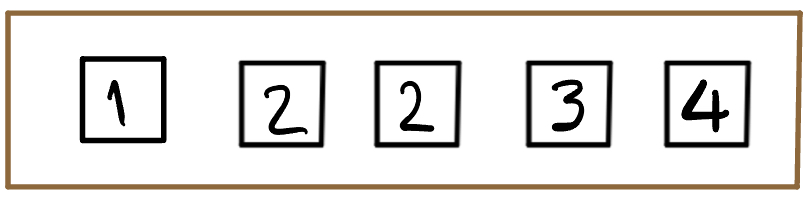

**Hình 1.1. Hộp có năm lá thăm, hai lá cùng ghi số 2.** Nguồn: `STAT20_in_Vietnamese.html`, §3.4.1.1. Bản ảnh gốc: `figures/stat20_hop_nam_la.jpg`.

Trong Hình 1.2, mỗi cột có bề rộng 1, đặt ở một giá trị nguyên. Chiều cao cột bằng xác suất; vì bề rộng 1 nên diện tích cột cũng bằng xác suất. Tổng diện tích là 1. Ta không cần rút mẫu để vẽ hình lý thuyết này.

Lý thuyết ngữ pháp đồ họa của Tuần 03 vẫn áp dụng: dữ liệu là bảng $(x,p_X(x))$, ánh xạ $x$ vào vị trí ngang và xác suất vào chiều cao, dạng hình học là cột. Thư viện vẽ hình không thay đổi ba thành phần đó. Với các giá trị không cách đều một đơn vị, cần phân biệt biểu đồ cột PMF với histogram có diện tích biểu diễn xác suất.

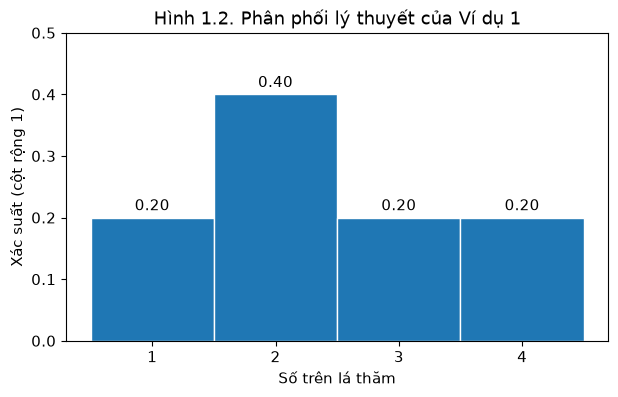

In [2]:
hop = np.array([1, 2, 2, 3, 4])
x_hop = np.arange(1, 5)
p_hop = np.array([1, 2, 1, 1]) / 5
assert np.isclose(p_hop.sum(), 1)
fig, ax = plt.subplots()
ax.bar(x_hop, p_hop, width=1, edgecolor='white', color='tab:blue')
ax.set(xticks=x_hop, ylim=(0, 0.5), xlabel='Số trên lá thăm',
       ylabel='Xác suất (cột rộng 1)', title='Hình 1.2. Phân phối lý thuyết của Ví dụ 1')
for x, p in zip(x_hop, p_hop):
    ax.text(x, p + 0.012, f'{p:.2f}', ha='center')
plt.show()

### Từ xác suất lý thuyết đến tần suất tương đối

Nếu rút có hoàn lại $m$ lần và thấy số $x$ xuất hiện $n_x$ lần, **tần suất tương đối** là

$$\widehat p_m(x)=\frac{n_x}{m}.$$

Ở đây $m$ là số lần lặp, $n_x$ là số lần thấy đúng giá trị $x$, và $\widehat p_m(x)$ là tỉ lệ trong dữ liệu đã thu được. Dấu mũ nhắc rằng đây là kết quả từ mẫu, có thể thay đổi khi ta mô phỏng lại. $p_X(x)$ là xác suất của mô hình, không phụ thuộc vào việc lần mô phỏng cụ thể ra kết quả gì.

Một mẫu 50 lần rút được ghi trên slide:

| $x$ | 1 | 2 | 3 | 4 |
|---|---:|---:|---:|---:|
| Số lần | 10 | 24 | 10 | 6 |
| Tần suất | 0,20 | 0,48 | 0,20 | 0,12 |

Chẳng hạn $\widehat p_{50}(2)=24/50=0{,}48$, khác $p_X(2)=0{,}40$. Đây là một mẫu được nguồn ghi lại, không phải đầu ra mà mọi seed phải tái tạo. Trước khi chạy ô kế tiếp, dự đoán: 50 lần rút có bắt buộc cho đúng 20 số 2 không?

In [3]:
mau_hop = rng.choice(hop, size=5000, replace=True)
tan_suat_hop = []
for m in [50, 500, 5000]:
    tan_suat = np.array([(mau_hop[:m] == k).mean() for k in x_hop])
    tan_suat_hop.append(tan_suat)
    print(f'{m:4d} lần rút:', np.round(tan_suat, 3))
display(pd.DataFrame(tan_suat_hop, index=[50, 500, 5000], columns=x_hop))

  50 lần rút: [0.18 0.34 0.28 0.2 ]
 500 lần rút: [0.21  0.394 0.212 0.184]
5000 lần rút: [0.206 0.4   0.195 0.199]


,1,2,3,4
50,0.180,0.3400,0.2800,0.2000
500,0.210,0.3940,0.2120,0.1840
5000,0.206,0.4004,0.1948,0.1988


`replace=True` đặt lại lá vừa rút trước lần tiếp theo, nên thành phần hộp luôn như cũ. `mau_hop[:m]` lấy $m$ kết quả đầu của cùng một chuỗi 5.000 lần rút. `(mau_hop[:m] == k)` tạo các giá trị đúng/sai; trung bình của chúng chính là tần suất số $k$.

Slide dùng seed 214 và in lần lượt $(0{,}26;0{,}34;0{,}20;0{,}20)$ với 50 lần, $(0{,}210;0{,}402;0{,}188;0{,}200)$ với 500 lần, và $(0{,}207;0{,}394;0{,}204;0{,}195)$ với 5.000 lần. Mẫu 50 lần ở trang 9 là một mẫu minh họa khác. Việc hai mẫu 50 lần cho hai bảng khác nhau không mâu thuẫn với cùng một phân phối xác suất.

Hình kế tiếp tái dựng ba biểu đồ của slide, giữ cùng thang đo để dễ so sánh. Cột là tần suất mô phỏng theo seed của notebook; điểm đỏ là xác suất lý thuyết.

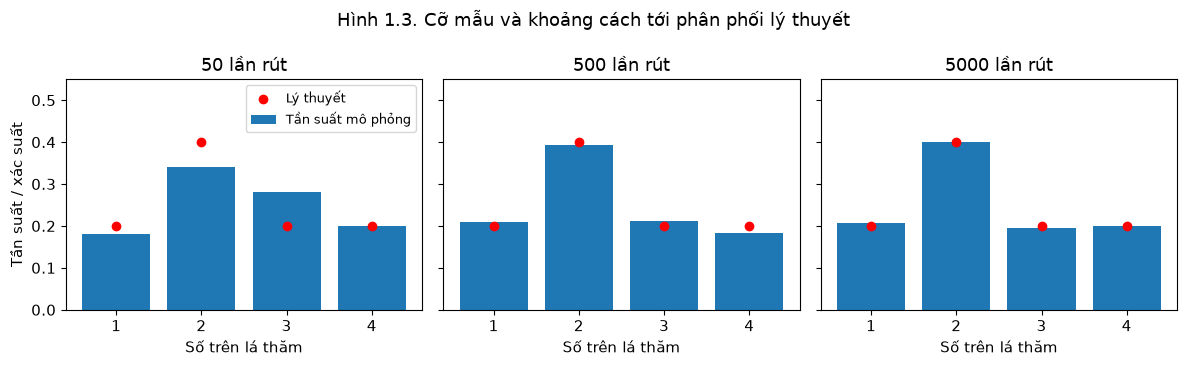

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.7), sharey=True)
for ax, m, ts in zip(axes, [50, 500, 5000], tan_suat_hop):
    ax.bar(x_hop, ts, width=0.8, label='Tần suất mô phỏng')
    ax.scatter(x_hop, p_hop, color='red', zorder=3, label='Lý thuyết')
    ax.set(title=f'{m} lần rút', xticks=x_hop, ylim=(0, 0.55), xlabel='Số trên lá thăm')
axes[0].set_ylabel('Tần suất / xác suất')
axes[0].legend(fontsize=9)
fig.suptitle('Hình 1.3. Cỡ mẫu và khoảng cách tới phân phối lý thuyết')
fig.tight_layout()
plt.show()

Khi tăng số lần rút, tần suất thường gần xác suất hơn, nhưng độ lệch không nhất thiết giảm sau **mỗi** lần thêm dữ liệu. Một mẫu 50 lần không bị yêu cầu chứa đúng 20 số 2. Xác suất 0,4 nói về cơ chế rút và tần suất dài hạn, không hứa trước kết quả của từng mẫu nhỏ.

**Thử trên notebook (bổ sung thao tác cho Ví dụ 1).** Đổi danh sách cỡ mẫu trong các ô trên, hoặc đổi seed ở ô thiết lập rồi chạy từ đầu. Chỉ ra cột nào cao hơn lý thuyết và cột nào thấp hơn. Không được đọc độ lệch mô phỏng là bằng chứng rằng hộp đã thay đổi.

### Ví dụ 2 — Tổng hai xúc xắc

Gieo độc lập hai xúc xắc cân đối. Một kết quả là cặp có thứ tự $(a,b)$ với $a,b\in\{1,\ldots,6\}$. Có $6\times6=36$ cặp đồng khả năng. Gọi $X=a+b$.

Tổng 2 chỉ ứng với $(1,1)$, nên $P(X=2)=1/36$. Tổng 7 ứng với sáu cặp $(1,6),(2,5),\ldots,(6,1)$, nên $P(X=7)=6/36=1/6$.

| Tổng $x$ | 2 | 3 | 4 | 5 | 6 | 7 | 8 | 9 | 10 | 11 | 12 |
|---|---:|---:|---:|---:|---:|---:|---:|---:|---:|---:|---:|
| Số cặp | 1 | 2 | 3 | 4 | 5 | 6 | 5 | 4 | 3 | 2 | 1 |

Không được chia đều xác suất cho 11 giá trị của tổng: các **cặp** đồng khả năng, còn mỗi tổng gom một số cặp khác nhau. Ô dưới liệt kê toàn bộ cặp để kiểm tra bảng, rồi mô phỏng 5.000 lần gieo hai xúc xắc.

Mảng mô phỏng có dạng: (5000, 2)
Tần suất tổng bằng 7: 0.161
Xác suất tổng bằng 7: 0.1667


,Tổng,Số cặp,Lý thuyết,Tần suất
0,2,1,0.027778,0.0274
1,3,2,0.055556,0.0562
2,4,3,0.083333,0.0888
3,5,4,0.111111,0.1148
4,6,5,0.138889,0.1410
5,7,6,0.166667,0.1610
6,8,5,0.138889,0.1380
7,9,4,0.111111,0.1126
8,10,3,0.083333,0.0876
9,11,2,0.055556,0.0484


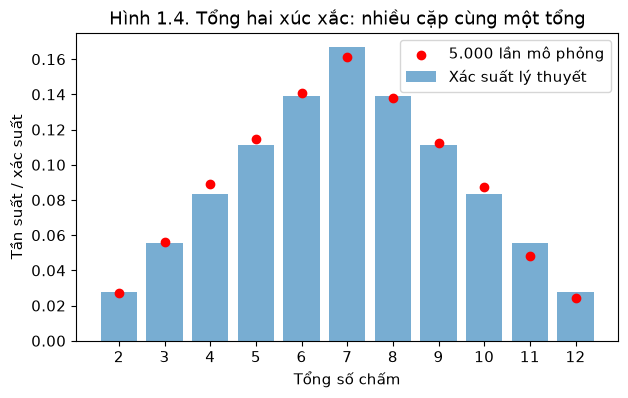

In [5]:
cap_xuc_xac = np.array(list(itertools.product(range(1, 7), repeat=2)))
x_dice = np.arange(2, 13)
p_dice = np.array([(cap_xuc_xac.sum(axis=1) == k).mean() for k in x_dice])
gieo_hai_xuc_xac = rng.integers(1, 7, size=(5000, 2))
tong_dice = gieo_hai_xuc_xac.sum(axis=1)
f_dice = np.array([(tong_dice == k).mean() for k in x_dice])
print('Mảng mô phỏng có dạng:', gieo_hai_xuc_xac.shape)
print('Tần suất tổng bằng 7:', round((tong_dice == 7).mean(), 4))
print('Xác suất tổng bằng 7:', round(6 / 36, 4))
display(pd.DataFrame({'Tổng': x_dice, 'Số cặp': np.rint(36*p_dice).astype(int),
                      'Lý thuyết': p_dice, 'Tần suất': f_dice}))
fig, ax = plt.subplots()
ax.bar(x_dice, p_dice, width=0.8, alpha=0.6, label='Xác suất lý thuyết')
ax.scatter(x_dice, f_dice, color='red', label='5.000 lần mô phỏng')
ax.set(xticks=x_dice, xlabel='Tổng số chấm', ylabel='Tần suất / xác suất',
       title='Hình 1.4. Tổng hai xúc xắc: nhiều cặp cùng một tổng')
ax.legend()
plt.show()

Mỗi hàng của mảng `(5000, 2)` chứa một cặp kết quả; `sum(axis=1)` cộng theo hàng. `integers(1, 7)` sinh số nguyên từ 1 đến 6, vì cận trên 7 không được lấy. Slide dùng seed 214 có tần suất tổng 7 là 0,1598; seed 42 của notebook có thể cho giá trị khác quanh 0,1667.

**Tự kiểm tra:** vì sao 2 và 12 có cùng xác suất? Vì mỗi tổng ứng với đúng một cặp đồng khả năng. Vì sao 6 và 8 có cùng xác suất? Mỗi tổng ứng với năm cặp. Tính đối xứng này xuất phát từ cơ chế gieo xúc xắc, không phụ thuộc vào việc một mẫu mô phỏng có đối xứng chính xác hay không.

## 2. Quy tắc đếm cơ bản — bổ sung theo đề cương §3.4.2

Để tính xác suất của một tổng, ta vừa đếm các cặp xúc xắc. Khi số kết quả lớn, liệt kê tất cả có thể bất tiện; quy tắc đếm giúp ta làm việc đó có hệ thống.

Nếu một công việc có $r$ bước và, sau mỗi lựa chọn trước đó, bước $j$ luôn có $k_j$ cách tiếp tục, số dãy kết quả là

$$k_1k_2\cdots k_r.$$

$r$ là số bước; $k_j$ là số lựa chọn ở bước thứ $j$. Công thức đếm không tự khẳng định các dãy đồng xác suất. Chỉ khi cơ chế chọn cho chúng cùng khả năng, ta mới tính xác suất bằng tỉ số số kết quả.

Geni có 3 áo và 2 quần. Với mỗi áo đều có 2 lựa chọn quần, nên có $3\times2=6$ bộ trang phục. Cây trong hình làm hiện rõ sáu đường đi từ việc chọn áo tới việc chọn quần.

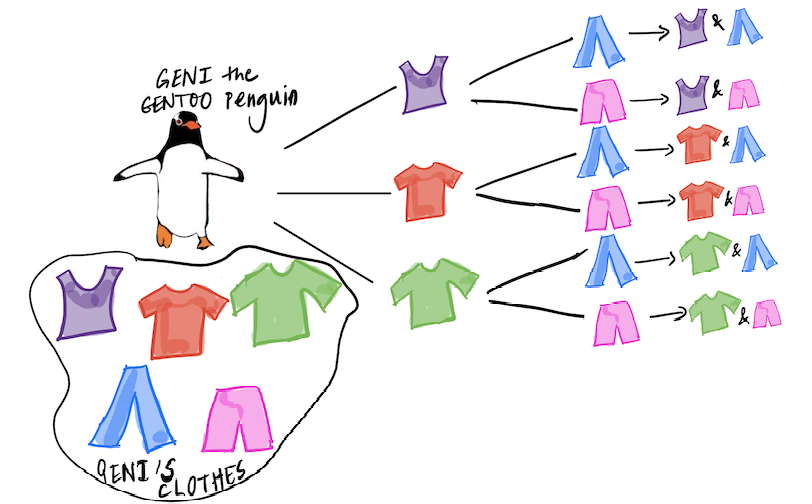

**Hình 2.1. Geni chọn một áo và một quần: 3 nhân 2 bằng 6 bộ.** Nguồn: `STAT20_in_Vietnamese.html`, §3.4.2. Bản ảnh gốc: `figures/stat20_geni_quy_tac_dem.png`.

### Chỉnh hợp và tổ hợp khác nhau ở vai trò của thứ tự

Hộp có năm lá chữ cái `C, R, A, T, E`. Nếu rút 3 lần **có hoàn lại** và ghi thứ tự, có $5^3=125$ dãy; `CCC` được phép. Nếu **không hoàn lại**, có $5\times4\times3=60$ dãy; `CRA` và `CAR` là hai dãy khác nhau.

Đó là **chỉnh hợp**. Với $n$ phần tử phân biệt, lấy $k$ phần tử không hoàn lại và có xét thứ tự, số cách là

$$A_n^k=\frac{n!}{(n-k)!}.$$

Ký hiệu $n!$ nghĩa là $n(n-1)\cdots1$; quy ước $0!=1$. Ở đây $0\leq k\leq n$ và cả hai là số nguyên. Nếu chỉ quan tâm **tập** ba chữ được lấy, sáu dãy `CRA, CAR, RCA, RAC, ACR, ARC` cùng đại diện cho một tập. Chia cho $3!=6$ để tránh đếm lặp; ta được $60/6=10$ tập con.

Đó là **tổ hợp**:

$$\binom nk=\frac{n!}{k!(n-k)!}.$$

Mỗi tập con có $k!$ thứ tự, nên cần chia số chỉnh hợp cho $k!$. Cụ thể, chia 5 lá bài từ bộ 52 lá mà không xét thứ tự cho $\binom{52}{5}=2\,598\,960$ bộ bài. `math.comb(n,k)` tính tổ hợp bằng số nguyên chính xác.

Trước khi chạy, giải thích bằng lời vì sao 60 và 10 đều đúng nhưng trả lời hai câu hỏi khác nhau.

In [6]:
chu_cai = ['C', 'R', 'A', 'T', 'E']
co_hoan_lai = list(itertools.product(chu_cai, repeat=3))
khong_hoan_lai = list(itertools.permutations(chu_cai, 3))
tap_con = list(itertools.combinations(chu_cai, 3))
print('Có hoàn lại, có thứ tự:', len(co_hoan_lai), '= 5^3')
print('Không hoàn lại, có thứ tự:', len(khong_hoan_lai), '= 5·4·3')
print('Không hoàn lại, không thứ tự:', len(tap_con), '= C(5,3)')
print('Các tập con:', tap_con)
print('Số bộ 5 lá bài:', f'{comb(52, 5):,}')
assert len(khong_hoan_lai) == factorial(3) * len(tap_con)

Có hoàn lại, có thứ tự: 125 = 5^3
Không hoàn lại, có thứ tự: 60 = 5·4·3
Không hoàn lại, không thứ tự: 10 = C(5,3)
Các tập con: [('C', 'R', 'A'), ('C', 'R', 'T'), ('C', 'R', 'E'), ('C', 'A', 'T'), ('C', 'A', 'E'), ('C', 'T', 'E'), ('R', 'A', 'T'), ('R', 'A', 'E'), ('R', 'T', 'E'), ('A', 'T', 'E')]
Số bộ 5 lá bài: 2,598,960


Trong bài toán siêu bội ở phần sau, mẫu là một tập lá thăm nên ta dùng tổ hợp. Trong bài toán nhị thức, ta chọn các **vị trí** thành công trong $n$ phép thử; số tập vị trí có kích thước $k$ cũng bằng $\binom nk$. Hai ứng dụng này dùng cùng cách đếm, nhưng cơ chế thử và xác suất của kết quả khác nhau.

## 3. Biến ngẫu nhiên gán con số cho kết quả của phép thử

### Ví dụ 3 — Ba lần tung đồng xu

Tung một đồng xu cân đối ba lần độc lập; `H` là ngửa và `T` là sấp. Mỗi kết quả $\omega$ là một chuỗi có thứ tự, chẳng hạn `HHT`. Đặt $X$ bằng số mặt ngửa trong chuỗi. Khi đó $X(\mathrm{HHT})=2$ và $X(\mathrm{TTT})=0$.

Một **biến ngẫu nhiên** là hàm

$$X:\Omega\longrightarrow\mathbb R.$$

$\Omega$ là không gian mẫu; $\omega\in\Omega$ là một kết quả của phép thử; $X(\omega)$ là số thực gắn với kết quả đó. Chữ in hoa $X$ chỉ hàm hoặc đại lượng trước khi biết kết quả, còn chữ thường $x$ chỉ một giá trị cụ thể.

Biến cố $\{X=2\}$ là tập $\{\mathrm{HHT},\mathrm{HTH},\mathrm{THH}\}$. Một số có thể được gán cho nhiều kết quả. Muốn có $P(X=2)$, ta cộng xác suất của tất cả kết quả được gán số 2.

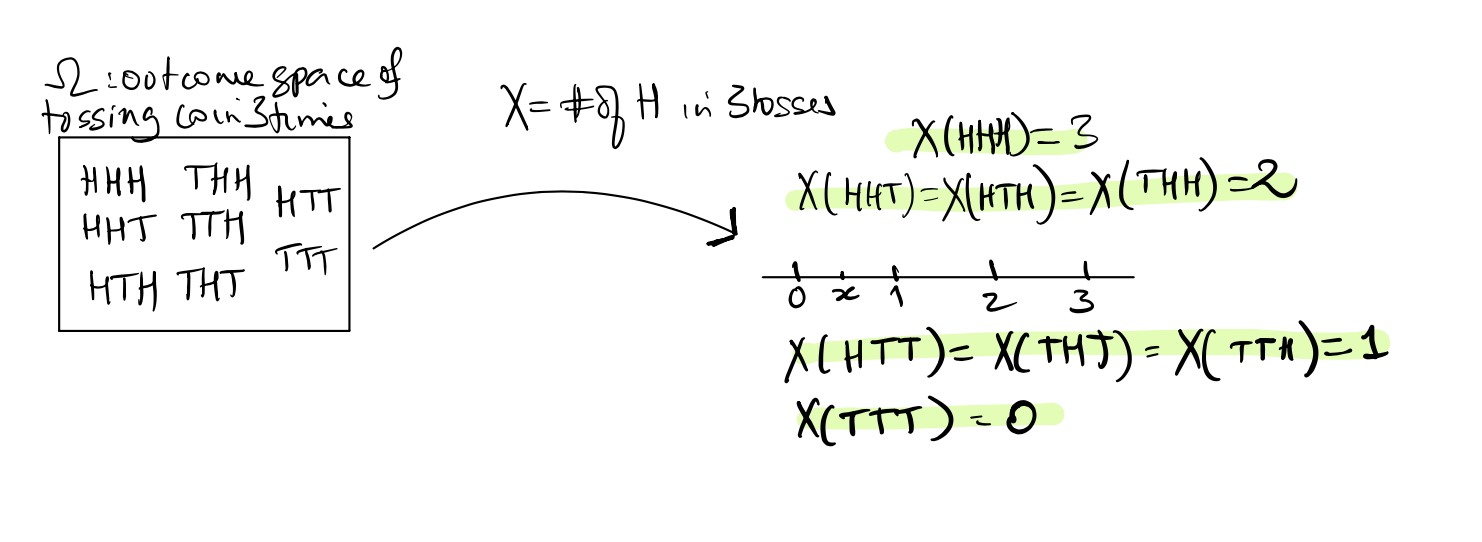

**Hình 3.1. Các chuỗi tung đồng xu được gán vào số mặt ngửa.** Nguồn: `STAT20_in_Vietnamese.html`, §4.1, Figure 5. Bản ảnh gốc: `figures/stat20_anh_xa_bien_ngau_nhien.png`.

In [7]:
omega_xu = [''.join(chuoi) for chuoi in itertools.product('HT', repeat=3)]
bang_xu = pd.DataFrame({'Kết quả ω': omega_xu})
bang_xu['X = số ngửa'] = bang_xu['Kết quả ω'].str.count('H')
bang_xu['Xác suất của ω'] = 1 / 8
display(bang_xu)
print('Biến cố {X=2}:', bang_xu.loc[bang_xu['X = số ngửa'] == 2, 'Kết quả ω'].tolist())

,Kết quả ω,X = số ngửa,Xác suất của ω
0,HHH,3,0.125
1,HHT,2,0.125
2,HTH,2,0.125
3,HTT,1,0.125
4,THH,2,0.125
5,THT,1,0.125
6,TTH,1,0.125
7,TTT,0,0.125


Biến cố {X=2}: ['HHT', 'HTH', 'THH']


### Rời rạc và liên tục

Biến ngẫu nhiên **rời rạc** nhận hữu hạn hoặc đếm được các giá trị. Số yêu cầu đến máy chủ trong một phút, số khách đến ATM trong một giờ, hay số lỗi chính tả đều là những số đếm. Một biến rời rạc có thể nhận vô hạn giá trị: số lần tung tới mặt ngửa đầu tiên là $1,2,3,\ldots$. Nó vẫn rời rạc.

Thời gian phản hồi của một dịch vụ, chiều cao của một người hoặc lượng mưa trong ngày thường được mô hình hóa bằng biến ngẫu nhiên **liên tục**, có thể biến thiên trên các khoảng của trục số. Số liệu được làm tròn khi đo không tự biến mô hình thời gian thành một số đếm. Buổi này tập trung vào rời rạc; cách mô tả xác suất liên tục được học ở Tuần 07.

### Ví dụ 4 — Hàm khối xác suất của số mặt ngửa

Với ba lần tung xu cân đối, tám chuỗi có cùng xác suất $1/8$. Có 1 chuỗi không có ngửa, 3 chuỗi có một ngửa, 3 chuỗi có hai ngửa và 1 chuỗi có ba ngửa:

| $x$ | 0 | 1 | 2 | 3 |
|---|---:|---:|---:|---:|
| $p_X(x)$ | $1/8$ | $3/8$ | $3/8$ | $1/8$ |

**Phân phối xác suất** của biến ngẫu nhiên rời rạc gồm các giá trị có thể nhận và xác suất tương ứng. **Hàm khối xác suất (probability mass function, PMF)** ghi thông tin đó bằng hàm:

$$p_X(x)=P(X=x).$$

PMF không âm, không vượt 1, và tổng trên mọi giá trị có thể nhận $S$ bằng 1:

$$0\leq p_X(x)\leq1,\qquad\sum_{x\in S}p_X(x)=1.$$

Với ví dụ này, $S=\{0,1,2,3\}$; ngoài tập này PMF bằng 0. Để tính xác suất biến cố gồm nhiều giá trị, cộng các khối xác suất tương ứng. Chẳng hạn $P(X\geq2)=p_X(2)+p_X(3)=3/8+1/8=1/2$.

,x,p_X(x)
0,0,0.125
1,1,0.375
2,2,0.375
3,3,0.125


P(X≥2) = 0.5


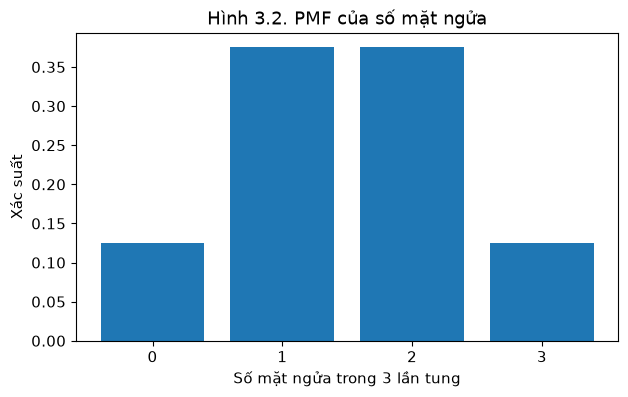

In [8]:
x_xu = np.arange(4)
p_xu = np.array([(bang_xu['X = số ngửa'] == x).mean() for x in x_xu])
display(pd.DataFrame({'x': x_xu, 'p_X(x)': p_xu}))
print('P(X≥2) =', p_xu[x_xu >= 2].sum())
assert np.isclose(p_xu.sum(), 1)
fig, ax = plt.subplots()
ax.bar(x_xu, p_xu, width=0.8)
ax.set(xticks=x_xu, xlabel='Số mặt ngửa trong 3 lần tung', ylabel='Xác suất',
       title='Hình 3.2. PMF của số mặt ngửa')
plt.show()

### Ví dụ 5 — Số ngửa trừ số sấp

Tung một đồng xu cân đối ba lần độc lập, giữ thứ tự kết quả. Đặt $X$ bằng số mặt ngửa **trừ** số mặt sấp.

1. Liệt kê mọi giá trị mà $X$ có thể nhận.
2. Với mỗi giá trị, liệt kê những kết quả tương ứng của phép thử.
3. Tính xác suất của từng giá trị. $X$ có thể bằng 0 không?

Hãy thử viết $X$ theo số ngửa $N$ trước khi nhìn đáp án; đây là cách tránh bỏ sót hoặc tự thêm một giá trị không thể xảy ra.

<details><summary>Đáp án và cách lập luận</summary><div><p>Vì số sấp bằng $3-N$, ta có $X=N-(3-N)=2N-3$. Với $N=0,1,2,3$, các giá trị của $X$ là $-3,-1,1,3$.</p> <table> <thead> <tr>   <th style="text-align:right">$x$</th>   <th>Kết quả tương ứng</th>   <th style="text-align:right">$P(X=x)$</th> </tr> </thead> <tbody> <tr>   <td style="text-align:right">$-3$</td>   <td>TTT</td>   <td style="text-align:right">$1/8$</td> </tr> <tr>   <td style="text-align:right">$-1$</td>   <td>HTT, THT, TTH</td>   <td style="text-align:right">$3/8$</td> </tr> <tr>   <td style="text-align:right">$1$</td>   <td>HHT, HTH, THH</td>   <td style="text-align:right">$3/8$</td> </tr> <tr>   <td style="text-align:right">$3$</td>   <td>HHH</td>   <td style="text-align:right">$1/8$</td> </tr> </tbody> </table> <p>Mỗi chuỗi có xác suất $1/8$, nên mỗi hàng nhận xác suất bằng số chuỗi trong hàng chia 8. $X=0$ đòi hỏi $N=1{,}5$, không phải một số ngửa có thể có. Do đó $P(X=0)=0$. Biến rời rạc không bắt buộc phải nhận mọi số nguyên giữa giá trị nhỏ nhất và lớn nhất.</p> </div></details>

In [9]:
bang_xu['Ngửa trừ sấp'] = 2 * bang_xu['X = số ngửa'] - 3
bang_hieu = bang_xu.groupby('Ngửa trừ sấp').agg(
    ket_qua=('Kết quả ω', lambda s: ', '.join(s)),
    xac_suat=('Xác suất của ω', 'sum'))
display(bang_hieu)
print('P(X=0) =', (bang_xu['Ngửa trừ sấp'] == 0).mean())

,ket_qua,xac_suat
Ngửa trừ sấp,,
-3,TTT,0.125
-1,"HTT, THT, TTH",0.375
1,"HHT, HTH, THH",0.375
3,HHH,0.125


P(X=0) = 0.0


PMF của số ngửa trừ số sấp có cùng các khối $1/8,3/8,3/8,1/8$ như số ngửa, nhưng nằm ở những vị trí khác. Đừng chỉ ghi các xác suất mà quên ghi **giá trị nào** mang xác suất đó.

### Đặt cược vào đỏ trong roulette — bổ sung theo đề cương §3.5.3

Roulette kiểu Mỹ có 38 ô: 18 đỏ, 18 đen và 2 xanh (0 và 00). Mô hình trong STAT 20 giả sử mỗi ô có cùng khả năng và các lượt quay độc lập. Cược 1 USD vào đỏ: trúng thì nhận lại 1 USD tiền gốc và lãi thêm 1 USD; trượt thì mất 1 USD. **Lãi ròng** của một lượt bằng $+1$ hoặc $-1$ USD, không phải $+2$ hoặc $0$.

Gọi $N$ là số lượt thắng khi cược vào đỏ sáu lượt, và $L$ là tổng lãi ròng. Ta có

$$L=N-(6-N)=2N-6.$$

$N$ nhận $0,1,\ldots,6$ nên $L$ nhận $-6,-4,-2,0,2,4,6$. Đây là biến ngẫu nhiên vì mỗi chuỗi kết quả sáu lượt được gán một tổng lãi cụ thể. Xác suất thắng một lượt là $18/38$, xác suất thua là $20/38$; việc chỉ có hai loại thắng/thua không làm chúng đồng khả năng.

Ô dưới mô phỏng sáu lượt cho mỗi người chơi, rồi đếm lãi ròng trên 10.000 lần lặp. Khi đến phân phối nhị thức, ta sẽ biết công thức đầy đủ của bảng lãi này.

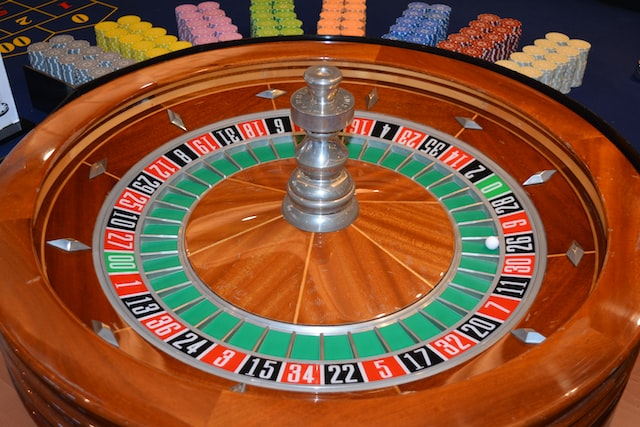

**Hình 3.3. Roulette trong ví dụ đặt cược vào đỏ.** Nguồn: `STAT20_in_Vietnamese.html`, §4.2, Figure 6. Bản ảnh gốc: `figures/stat20_roulette.jpg`.

,Lãi ròng (USD),Tần suất mô phỏng
0,-6,0.0220
1,-4,0.1182
2,-2,0.2608
3,0,0.3121
4,2,0.2016
5,4,0.0745
6,6,0.0108


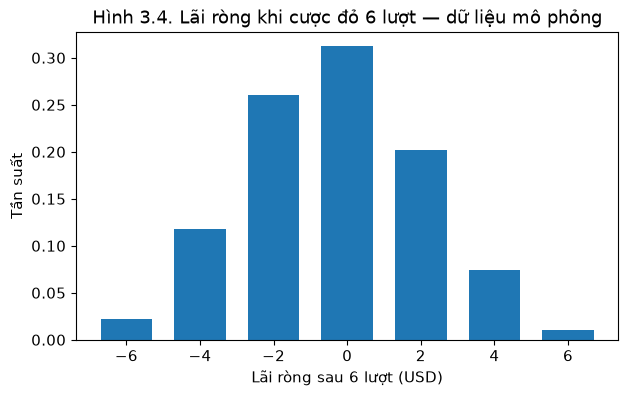

In [10]:
so_luot = 6
so_lan_lap = 10000
p_do = 18 / 38
thang = rng.random((so_lan_lap, so_luot)) < p_do
so_thang = thang.sum(axis=1)
lai_rong = 2 * so_thang - so_luot
gia_tri_lai = np.arange(-6, 7, 2)
ts_lai = np.array([(lai_rong == k).mean() for k in gia_tri_lai])
display(pd.DataFrame({'Lãi ròng (USD)': gia_tri_lai, 'Tần suất mô phỏng': ts_lai}))
fig, ax = plt.subplots()
ax.bar(gia_tri_lai, ts_lai, width=1.4)
ax.set(xticks=gia_tri_lai, xlabel='Lãi ròng sau 6 lượt (USD)', ylabel='Tần suất',
       title='Hình 3.4. Lãi ròng khi cược đỏ 6 lượt — dữ liệu mô phỏng')
plt.show()

Lãi 0 nghĩa là thắng 3 và thua 3; lãi 6 nghĩa là thắng cả sáu. Sáu lượt thắng không có xác suất $1/7$: các giá trị lãi gom các số lượng chuỗi thắng/thua khác nhau, và xác suất thắng/thua của từng lượt cũng khác nhau.

**Tự kiểm tra:** nếu thắng 4, thua 2 thì lãi ròng bằng bao nhiêu? Bằng $4-2=2$ USD. Việc nhận lại tiền gốc ở các lượt thắng không tạo thêm lãi. Kỳ vọng lãi dài hạn sẽ được học ở Tuần 07.

## 4. Hàm phân phối tích lũy trả lời câu hỏi về ngưỡng

### Ví dụ 6 — Hai sản phẩm được kiểm tra độc lập

Mỗi sản phẩm đạt chuẩn với xác suất 0,8. Gọi $X$ là số sản phẩm đạt chuẩn trong hai sản phẩm.

- Không có sản phẩm đạt: $(0{,}2)^2=0{,}04$.
- Đúng một sản phẩm đạt: đạt–trượt hoặc trượt–đạt, nên $2(0{,}8)(0{,}2)=0{,}32$.
- Cả hai đạt: $(0{,}8)^2=0{,}64$.

| $x$ | 0 | 1 | 2 |
|---|---:|---:|---:|
| $p_X(x)$ | 0,04 | 0,32 | 0,64 |

Nếu muốn biết xác suất **không quá một** sản phẩm đạt chuẩn, phải cộng $0{,}04+0{,}32=0{,}36$. Để tính lặp lại những câu hỏi như vậy, ta dùng **hàm phân phối tích lũy (cumulative distribution function, CDF)**:

$$F_X(t)=P(X\leq t)=\sum_{x\leq t}p_X(x).$$

$t$ là ngưỡng bất kỳ trên trục số thực. Dù $X$ rời rạc, $F_X$ được định nghĩa cho **mọi** số thực. Tổng lấy các giá trị $x$ không vượt quá $t$, kể cả giá trị đúng bằng $t$.

### Lập CDF từng khoảng

Với Ví dụ 6:

$$
F_X(t)=\begin{cases}
0,&t<0,\\
0{,}04,&0\leq t<1,\\
0{,}36,&1\leq t<2,\\
1,&t\geq2.
\end{cases}
$$

CDF không giảm, nằm trong $[0,1]$, tiến tới 0 khi ngưỡng tiến về $-\infty$ và tiến tới 1 khi ngưỡng tiến về $+\infty$. Với $a<b$,

$$P(a<X\leq b)=F_X(b)-F_X(a).$$

Phép trừ loại toàn bộ phần xác suất tại và dưới $a$, nên đầu trái là dấu $<$; đầu phải vẫn là $\leq$. Ví dụ $P(0<X\leq2)=1-0{,}04=0{,}96$, xác suất có ít nhất một sản phẩm đạt.

Ở giá trị $x$ có khối xác suất dương, CDF nhảy một đoạn bằng $p_X(x)$. Nó **liên tục bên phải**: giá trị tại điểm nhảy bằng đầu trên của bước nhảy. Hình kế tiếp dùng chấm đặc cho giá trị được lấy, vòng tròn rỗng cho giới hạn phía trái.

,x,p_X(x),F_X(x)
0,0,0.04,0.04
1,1,0.32,0.36
2,2,0.64,1.00


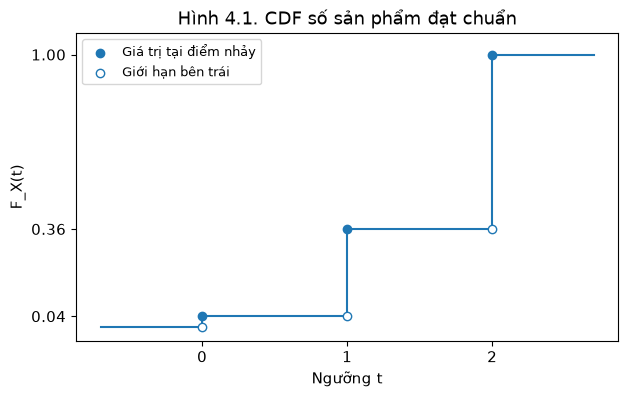

In [11]:
x_sp = np.array([0, 1, 2])
p_sp = np.array([0.04, 0.32, 0.64])
F_sp = p_sp.cumsum()
display(pd.DataFrame({'x': x_sp, 'p_X(x)': p_sp, 'F_X(x)': F_sp}))
fig, ax = plt.subplots()
ax.step([-0.7, 0, 1, 2, 2.7], [0, 0.04, 0.36, 1, 1], where='post')
ax.scatter(x_sp, F_sp, color='tab:blue', zorder=3, label='Giá trị tại điểm nhảy')
ax.scatter(x_sp, np.r_[0, F_sp[:-1]], facecolors='white', edgecolors='tab:blue',
           zorder=4, label='Giới hạn bên trái')
ax.set(xticks=x_sp, yticks=[0.04, 0.36, 1], ylim=(-0.05, 1.08),
       xlabel='Ngưỡng t', ylabel='F_X(t)', title='Hình 4.1. CDF số sản phẩm đạt chuẩn')
ax.legend(fontsize=9)
plt.show()

Tại $t=1$, CDF bằng 0,36, không phải 0,04. Độ nhảy $0{,}36-0{,}04=0{,}32$ chính là xác suất đúng một sản phẩm đạt. Với ngưỡng 1,5, chưa thêm giá trị nào của $X$, nên $F_X(1{,}5)=F_X(1)=0{,}36$. Đây là lý do CDF rời rạc có các đoạn ngang.

### Ví dụ 7 — Tính xác suất chỉ từ CDF

Vẫn xét hai sản phẩm độc lập với xác suất đạt 0,8. PMF tại $0,1,2$ lần lượt là $0{,}04,0{,}32,0{,}64$.

Tính $P(X<2)$ và $P(X=1)$ chỉ bằng các giá trị $F_X$. Trước khi tính, viết lại biến cố bằng các giá trị nguyên có thể có của $X$.

<details><summary>Đáp án và cách lập luận</summary><div><p>Vì $X$ chỉ nhận $0,1,2$, ta có $P(X&lt;2)=P(X\leq1)=F_X(1)=0{,}36$.</p> <p>Xác suất tại 1 là độ nhảy của CDF:</p> <p>$$P(X=1)=F_X(1)-F_X(0)=0{,}36-0{,}04=0{,}32.$$</p> <p>Không dùng $F_X(2)$ cho biến cố $X&lt;2$: giá trị đó bao gồm cả trường hợp hai sản phẩm đều đạt. Công thức $P(X=k)=F_X(k)-F_X(k-1)$ áp dụng khi $X$ nhận giá trị nguyên; tổng quát phải lấy độ nhảy $F_X(x)-F_X(x^-)$, tức trừ giới hạn trái.</p> </div></details>

In [12]:
print('P(X<2) = F(1) =', round(F_sp[1], 2))
print('P(X=1) = F(1)-F(0) =', round(F_sp[1]-F_sp[0], 2))
print('P(0<X≤2) = F(2)-F(0) =', round(F_sp[2]-F_sp[0], 2))

P(X<2) = F(1) = 0.36
P(X=1) = F(1)-F(0) = 0.32
P(0<X≤2) = F(2)-F(0) = 0.96


### Ví dụ 8 — Sáu đường dây điện thoại

Một doanh nghiệp có sáu đường dây. Tại thời điểm quan sát, số đường đang được sử dụng là $X$, có PMF sau:

| $x$ | 0 | 1 | 2 | 3 | 4 | 5 | 6 |
|---|---:|---:|---:|---:|---:|---:|---:|
| $p_X(x)$ | 0,10 | 0,15 | 0,20 | 0,25 | 0,20 | 0,06 | 0,04 |

1. Tính xác suất nhiều nhất ba đường đang dùng.
2. Tính xác suất ít hơn ba đường đang dùng.
3. Tính xác suất có từ hai đến bốn đường **chưa** dùng, gồm cả hai đầu mút.
4. Lập $F_X$ cho mọi số thực và vẽ đồ thị.

Lưu ý biến trong bảng là số đường **đang dùng**. Để giải câu 3, trước tiên đổi điều kiện về đúng biến đó.

<details><summary>Đáp án và cách lập luận</summary><div><ol> <li>$P(X\leq3)=0{,}10+0{,}15+0{,}20+0{,}25=0{,}70$.</li> <li>$P(X&lt;3)=0{,}10+0{,}15+0{,}20=0{,}45$.</li> <li>Gọi $Y=6-X$ là số đường chưa dùng. Điều kiện $2\leq Y\leq4$ tương đương $2\leq6-X\leq4$, rồi $2\leq X\leq4$. Do đó xác suất bằng $0{,}20+0{,}25+0{,}20=0{,}65$.</li> <li>Cộng dồn PMF:</li> </ol> <p>$$F_X(t)=\begin{cases} 0,&amp;t&lt;0,\\ 0{,}10,&amp;0\leq t&lt;1,\\ 0{,}25,&amp;1\leq t&lt;2,\\ 0{,}45,&amp;2\leq t&lt;3,\\ 0{,}70,&amp;3\leq t&lt;4,\\ 0{,}90,&amp;4\leq t&lt;5,\\ 0{,}96,&amp;5\leq t&lt;6,\\ 1,&amp;t\geq6. \end{cases}$$</p> <p>“Nhiều nhất ba” gồm giá trị 3; “ít hơn ba” không gồm 3. Chênh lệch $0{,}70-0{,}45=0{,}25$ chính là xác suất có đúng ba đường dùng.</p> </div></details>

Nhiều nhất 3: 0.7
Ít hơn 3: 0.45
Từ 2 đến 4 đường chưa dùng: 0.65


,x,p_X(x),F_X(x)
0,0,0.10,0.10
1,1,0.15,0.25
2,2,0.20,0.45
3,3,0.25,0.70
4,4,0.20,0.90
5,5,0.06,0.96
6,6,0.04,1.00


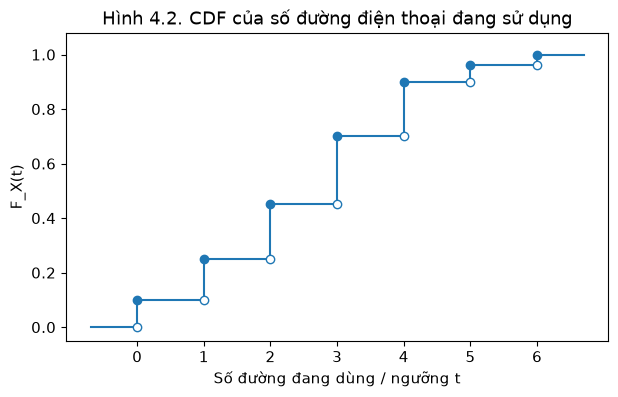

In [13]:
x_dien_thoai = np.arange(7)
p_dien_thoai = np.array([0.10, 0.15, 0.20, 0.25, 0.20, 0.06, 0.04])
F_dien_thoai = p_dien_thoai.cumsum()
assert np.isclose(p_dien_thoai.sum(), 1)
print('Nhiều nhất 3:', p_dien_thoai[x_dien_thoai <= 3].sum())
print('Ít hơn 3:', p_dien_thoai[x_dien_thoai < 3].sum())
print('Từ 2 đến 4 đường chưa dùng:', p_dien_thoai[(6-x_dien_thoai >= 2) & (6-x_dien_thoai <= 4)].sum())
display(pd.DataFrame({'x': x_dien_thoai, 'p_X(x)': p_dien_thoai, 'F_X(x)': F_dien_thoai}))
fig, ax = plt.subplots()
ax.step(np.r_[-0.7, x_dien_thoai, 6.7], np.r_[0, F_dien_thoai, 1], where='post')
ax.scatter(x_dien_thoai, F_dien_thoai, color='tab:blue', zorder=3)
ax.scatter(x_dien_thoai, np.r_[0, F_dien_thoai[:-1]], facecolors='white',
           edgecolors='tab:blue', zorder=4)
ax.set(xticks=x_dien_thoai, ylim=(-0.05, 1.08), xlabel='Số đường đang dùng / ngưỡng t',
       ylabel='F_X(t)', title='Hình 4.2. CDF của số đường điện thoại đang sử dụng')
plt.show()

Độ nhảy tại 3 là $F_X(3)-F_X(2)=0{,}70-0{,}45=0{,}25$. Tổng của tất cả bước nhảy là 1. Nếu thay một xác suất trong bảng mà không điều chỉnh các xác suất khác, hãy kiểm tra tổng vẫn bằng 1 trước khi gọi bảng đó là PMF.

**Một lỗi dễ gặp:** viết $P(2\leq X\leq4)=F_X(4)-F_X(2)$ sẽ bỏ mất khối tại 2. Với biến nguyên này, công thức đúng là $F_X(4)-F_X(1)=0{,}90-0{,}25=0{,}65$.

## 5. Các phân phối rời rạc thông dụng

Một **tham số** là con số xác định phân phối trong một họ mô hình. Biết tên mô hình mà không biết tham số chưa đủ để tính xác suất. Cùng là nhị thức nhưng $(n,p)=(20,0{,}25)$ và $(12,0{,}95)$ mô tả hai thí nghiệm khác nhau.

### Ví dụ 9 — Phân phối đều rời rạc

Nếu $X$ nhận $m$ giá trị phân biệt với cùng xác suất, nó có **phân phối đều rời rạc**. Trên $\{1,\ldots,m\}$:

$$P(X=k)=\frac1m,\qquad k=1,\ldots,m.$$

$m$ là số giá trị có thể nhận. Tổng quát, các giá trị không cần liên tiếp; chỉ cần có $m$ giá trị phân biệt, mỗi giá trị nhận $1/m$. Một biến cố gồm $r$ giá trị có xác suất $r/m$.

Một xúc xắc cân đối có $m=6$, nên mỗi mặt có xác suất $1/6$. $P(X\geq5)=P(X=5)+P(X=6)=2/6=1/3$. Dự đoán trước: nếu ghi tổng hai xúc xắc thay vì số chấm của một xúc xắc thì phân phối có còn đều không?

P(X≥5) = 0.3333333333333333


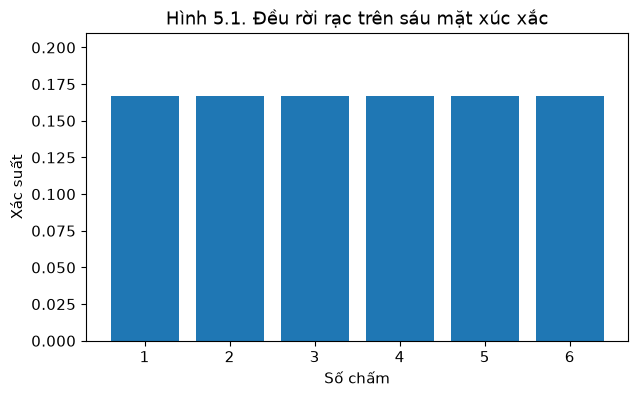

In [14]:
x_deu = np.arange(1, 7)
p_deu = stats.randint.pmf(x_deu, low=1, high=7)
print('P(X≥5) =', p_deu[x_deu >= 5].sum())
fig, ax = plt.subplots()
ax.bar(x_deu, p_deu, width=0.8)
ax.set(xticks=x_deu, ylim=(0, 0.21), xlabel='Số chấm', ylabel='Xác suất',
       title='Hình 5.1. Đều rời rạc trên sáu mặt xúc xắc')
plt.show()

Tổng hai xúc xắc không đều vì mỗi tổng ứng với số cặp khác nhau, như Ví dụ 2. Trong SciPy, `randint(low=1, high=7)` nhận các giá trị 1 đến 6; cũng giống NumPy, cận trên được loại.

### Ví dụ 10 — Bernoulli và cách mã hóa 0/1

Một phép thử có hai loại kết quả. Gọi loại đang quan tâm là “thành công”, mã hóa bằng 1; loại còn lại bằng 0. Nếu xác suất thành công là $p$, ta viết

$$X\sim\operatorname{Bernoulli}(p),\qquad P(X=1)=p,\quad P(X=0)=1-p.$$

$p\in[0,1]$ là tham số. “Thành công” là quy ước tên gọi, có thể là một kết quả không mong muốn như phát hiện linh kiện lỗi. Chọn cách mã hóa trước khi xác định $p$.

Ví dụ 10 tung một đồng xu một lần, $X=1$ khi ngửa, $X=0$ khi sấp. Ba hình tương ứng $p=1/2,3/4,2/3$. Quan sát xem khối tại 0 thay đổi thế nào khi khối tại 1 tăng.

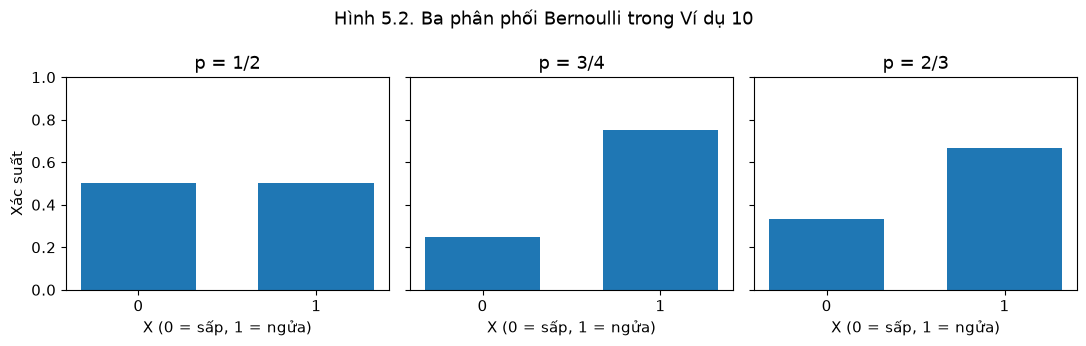

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3.5), sharey=True)
for ax, p, nhan in zip(axes, [1/2, 3/4, 2/3], ['1/2', '3/4', '2/3']):
    ax.bar([0, 1], stats.bernoulli.pmf([0, 1], p=p), width=0.65)
    ax.set(xticks=[0, 1], ylim=(0, 1), title=f'p = {nhan}', xlabel='X (0 = sấp, 1 = ngửa)')
axes[0].set_ylabel('Xác suất')
fig.suptitle('Hình 5.2. Ba phân phối Bernoulli trong Ví dụ 10')
fig.tight_layout()
plt.show()

Trong cả ba hình, hai chiều cao cộng thành 1. Bernoulli không yêu cầu $p=1/2$. Nếu $p=0$ thì $X$ luôn bằng 0; nếu $p=1$ thì $X$ luôn bằng 1. Đây vẫn là những trường hợp Bernoulli hợp lệ.

### Ví dụ 11 — Từ một số chọn đều tới một biến chỉ báo

Chọn ngẫu nhiên $N\in\{1,2,\ldots,1000\}$, mỗi số có cùng xác suất.

1. Tính xác suất $N$ chia hết cho 3, cho 5 và cho 15.
2. Đặt $Y=1$ nếu $N$ chia hết cho 3, $Y=0$ nếu không. Xác định phân phối của $Y$.

Đếm bội trong tập hữu hạn rồi mới chia cho 1.000; không dùng $1/3$ như một giá trị chính xác khi 1.000 không chia hết cho 3.

<details><summary>Đáp án và cách lập luận</summary><div><p>Có $\lfloor1000/3\rfloor=333$ bội của 3, $\lfloor1000/5\rfloor=200$ bội của 5 và $\lfloor1000/15\rfloor=66$ bội của 15. Vì các số đồng khả năng:</p> <p>$$P(N\text{ chia hết cho }3)=333/1000=0{,}333,$$</p> <p>$$P(N\text{ chia hết cho }5)=0{,}200,\qquad P(N\text{ chia hết cho }15)=0{,}066.$$</p> <p>$Y\sim\operatorname{Bernoulli}(0{,}333)$, với $P(Y=1)=0{,}333$ và $P(Y=0)=0{,}667$. $N$ đều trên 1.000 giá trị; $Y$ không đều trên hai giá trị vì 333 số được gán 1 và 667 số được gán 0.</p> </div></details>

In [16]:
so_nguyen = np.arange(1, 1001)
for d in [3, 5, 15]:
    chia_het = so_nguyen % d == 0
    print(f'Chia hết cho {d:2d}: {chia_het.sum():3d} số, xác suất {chia_het.mean():.3f}')
Y_chia_3 = (so_nguyen % 3 == 0).astype(int)
print('PMF của Y:', {0: (Y_chia_3 == 0).mean(), 1: (Y_chia_3 == 1).mean()})

Chia hết cho  3: 333 số, xác suất 0.333
Chia hết cho  5: 200 số, xác suất 0.200
Chia hết cho 15:  66 số, xác suất 0.066
PMF của Y: {0: np.float64(0.667), 1: np.float64(0.333)}


Ô này duyệt toàn bộ 1.000 giá trị nên kết quả là xác suất **chính xác** của tập chọn đều, không phải một tần suất xấp xỉ từ mẫu. Cùng phép tính `.mean()` có thể cho xác suất chính xác khi ta liệt kê toàn bộ các kết quả đồng khả năng, hoặc cho tần suất khi ta chỉ mô phỏng một mẫu; phải biết mình đang dùng dữ liệu nào.

### Phân phối nhị thức: đếm thành công trong số lần thử cố định

Từ một phép thử Bernoulli, lặp $n$ lần rồi đếm thành công. Mô hình **nhị thức** đòi hỏi bốn điều kiện:

1. Số phép thử $n$ cố định trước.
2. Mỗi phép thử có hai loại kết quả theo cách mã hóa.
3. Các phép thử độc lập.
4. Xác suất thành công $p$ không đổi.

Nếu $X$ là số thành công, ta viết $X\sim\operatorname{Binomial}(n,p)$. Với $0<p<1$:

$$P(X=k)=\binom nk p^k(1-p)^{n-k},\qquad k=0,1,\ldots,n.$$

$n$ là số lần thử; $p$ là xác suất thành công ở một lần; $k$ là số thành công trong biến cố đang tính. Một chuỗi cụ thể có $k$ thành công và $n-k$ thất bại có xác suất $p^k(1-p)^{n-k}$ do độc lập. Có $\binom nk$ cách chọn các vị trí thành công; các chuỗi xung khắc nên cộng xác suất bằng cách nhân với số chuỗi.

Ví dụ, kiểm tra độc lập 12 linh kiện trên một dây chuyền ổn định xem có lỗi không có thể đáp ứng mô hình. Nếu kết quả cùng phụ thuộc vào một lô nguyên liệu hỏng, điều kiện độc lập cần xét lại. Với $p=0$, $X$ luôn bằng 0; với $p=1$, $X$ luôn bằng $n$.

### Ví dụ 12 — Làm ngẫu nhiên một bài trắc nghiệm

Bài có 20 câu, mỗi câu bốn phương án và chỉ một phương án đúng. Sinh viên chọn một phương án ngẫu nhiên cho mỗi câu, độc lập giữa các câu. Gọi $X$ là số câu đúng.

1. Xác định phân phối và tham số của $X$.
2. Tính xác suất đúng 8 câu.
3. Tính xác suất đúng **nhiều hơn 2** câu.

Giải thích từng điều kiện của nhị thức; câu 3 có gồm trường hợp đúng 2 không?

<details><summary>Đáp án và cách lập luận</summary><div><p>Có 20 phép thử cố định, mỗi lần đúng/sai, độc lập theo đề bài, và xác suất đúng là $1/4=0{,}25$. Vì vậy $X\sim\operatorname{Binomial}(20,0{,}25)$.</p> <p>$$P(X=8)=\binom{20}{8}(0{,}25)^8(0{,}75)^{12}\approx0{,}0609.$$</p> <p>Đúng nhiều hơn 2 là $X=3,\ldots,20$, nên thuận tiện hơn khi dùng phần bù:</p> <p>$$P(X&gt;2)=1-P(X\leq2)=1-\sum_{k=0}^{2}\binom{20}{k}(0{,}25)^k(0{,}75)^{20-k}\approx0{,}9087.$$</p> <p>Theo mô hình đoán ngẫu nhiên này, xác suất đạt đúng 8 câu khoảng 6,09%, còn xác suất đạt ít nhất 3 câu khoảng 90,87%. Các con số không mô tả sinh viên đã biết một số đáp án nếu xác suất đúng của từng câu không còn bằng 0,25.</p> </div></details>

In [17]:
p_dung_8_tay = comb(20, 8) * 0.25**8 * 0.75**12
p_hon_2_tay = 1 - sum(comb(20, k) * 0.25**k * 0.75**(20-k) for k in range(3))
print('P(X=8): tính công thức =', round(p_dung_8_tay, 4),
      '; SciPy =', round(stats.binom.pmf(8, n=20, p=0.25), 4))
print('P(X>2): tính phần bù =', round(p_hon_2_tay, 4),
      '; SciPy sf(2) =', round(stats.binom.sf(2, n=20, p=0.25), 4))
doan_bai = (rng.random((10000, 20)) < 0.25).sum(axis=1)
print('Mô phỏng P(X=8):', round((doan_bai == 8).mean(), 4))
print('Mô phỏng P(X>2):', round((doan_bai > 2).mean(), 4))
assert np.isclose(p_dung_8_tay, stats.binom.pmf(8, 20, 0.25))
assert np.isclose(p_hon_2_tay, stats.binom.sf(2, 20, 0.25))

P(X=8): tính công thức = 0.0609 ; SciPy = 0.0609
P(X>2): tính phần bù = 0.9087 ; SciPy sf(2) = 0.9087
Mô phỏng P(X=8): 0.0637
Mô phỏng P(X>2): 0.9089


Mỗi hàng mô phỏng một bài, mỗi cột một câu; tổng các giá trị đúng/sai cho số câu đúng. Sai khác giữa tần suất và công thức là dao động mô phỏng.

Để xem vai trò của tham số, Hình 5.3 giữ $n=20$ và cho thay đổi $p$. Trước khi kéo thanh trượt, dự đoán: khi $p$ tăng, những giá trị $k$ mang nhiều xác suất sẽ chuyển sang phía nào? Rê chuột để đọc xác suất ở từng số câu đúng. Thanh trượt minh họa họ mô hình nhị thức, không còn là bài đoán bốn phương án khi $p\ne0{,}25$.

In [18]:
k_bin = np.arange(21)
p_grid = [0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95]
fig = go.Figure()
for p in p_grid:
    fig.add_trace(go.Bar(x=k_bin, y=stats.binom.pmf(k_bin, n=20, p=p),
        name=f'p = {p:.2f}', visible=(p == 0.25),
        hovertemplate='Số thành công k=%{x}<br>P(X=k)=%{y:.5f}<extra></extra>'))
steps = []
for i, p in enumerate(p_grid):
    hien = [j == i for j in range(len(p_grid))]
    steps.append(dict(method='update', label=f'{p:.2f}', args=[{'visible': hien}]))
fig.update_layout(title='Hình 5.3. Nhị thức n = 20: đổi xác suất thành công p',
    xaxis_title='Số thành công k', yaxis_title='P(X=k)',
    xaxis=dict(dtick=1), yaxis=dict(range=[0, 0.42]), showlegend=False,
    sliders=[dict(active=2, currentvalue={'prefix': 'p = '}, steps=steps)], height=430)
fig.show()

Khi $p$ tăng, xác suất tập trung ở các giá trị $k$ lớn hơn. Phân phối ở $p=0{,}5$ đối xứng; $p$ gần 0 hoặc gần 1 cho dạng lệch. Dạng hình không đủ để chọn mô hình nếu cơ chế thử không đáp ứng bốn điều kiện nhị thức.

Quay lại roulette: số lần thắng $N$ trong sáu lượt độc lập có $N\sim\operatorname{Binomial}(6,18/38)$. Vì $L=2N-6$, để có $L=2$ cần đúng bốn lượt thắng. Ô dưới dùng công thức để kiểm tra bảng mô phỏng ở mục 3.

In [19]:
p_lai_ly_thuyet = stats.binom.pmf(np.arange(7), n=6, p=18/38)
display(pd.DataFrame({'Lãi ròng (USD)': gia_tri_lai,
                      'Xác suất lý thuyết': p_lai_ly_thuyet,
                      'Tần suất đã mô phỏng': ts_lai}))
print('P(L=2) = P(N=4) =', round(stats.binom.pmf(4, n=6, p=18/38), 4))

,Lãi ròng (USD),Xác suất lý thuyết,Tần suất đã mô phỏng
0,-6,0.021256,0.0220
1,-4,0.114782,0.1182
2,-2,0.258259,0.2608
3,0,0.309910,0.3121
4,2,0.209189,0.2016
5,4,0.075308,0.0745
6,6,0.011296,0.0108


P(L=2) = P(N=4) = 0.2092


Một bảng có bảy mức lãi không phải phân phối đều; bảng lý thuyết xác nhận điều này. Mô phỏng và công thức đang mô tả cùng một biến ngẫu nhiên khi dùng cùng quy tắc lãi ròng.

### Ví dụ 13 — Sản phẩm đạt chuẩn

Dây chuyền có xác suất sản phẩm đạt chuẩn 0,95. Chọn độc lập 12 sản phẩm; $X$ là số sản phẩm đạt chuẩn.

1. Xác định phân phối của $X$.
2. Tính xác suất đúng 11 sản phẩm đạt.
3. Tính xác suất **ít nhất** 11 sản phẩm đạt.

Ở đây “thành công” là đạt chuẩn, còn trong ví dụ đếm linh kiện lỗi “thành công” có thể là lỗi. Chọn đúng $p$ theo đại lượng đang đếm.

<details><summary>Đáp án và cách lập luận</summary><div><p>$X\sim\operatorname{Binomial}(12,0{,}95)$.</p> <p>$$P(X=11)=\binom{12}{11}(0{,}95)^{11}(0{,}05)\approx0{,}3413.$$</p> <p>$$P(X\geq11)=P(X=11)+P(X=12)\approx0{,}8816.$$</p> <p>Đúng 11 có xác suất khoảng 34,13%; ít nhất 11 có xác suất khoảng 88,16%, vì bao gồm cả 12. Slide làm tròn ba chữ số thành 0,341 và 0,882.</p> </div></details>

In [20]:
print('Đúng 11 đạt:', round(stats.binom.pmf(11, n=12, p=0.95), 4))
print('Ít nhất 11 đạt:', round(stats.binom.sf(10, n=12, p=0.95), 4))
print('Cả 12 đạt:', round(stats.binom.pmf(12, n=12, p=0.95), 4))

Đúng 11 đạt: 0.3413
Ít nhất 11 đạt: 0.8816
Cả 12 đạt: 0.5404


`sf(10)` tính $P(X>10)=P(X\geq11)$ khi $X$ nguyên. `sf(11)` sẽ chỉ tính $P(X>11)=P(X=12)$, bỏ mất trường hợp đúng 11.

### Phân phối siêu bội: rút không hoàn lại từ hộp hữu hạn

Hộp có $N$ lá thăm phân biệt, trong đó $K$ lá ghi 1 và $N-K$ lá ghi 0. Rút ngẫu nhiên $n$ lá **không hoàn lại**; mọi tập $n$ lá có cùng khả năng. Gọi $X$ là số lá ghi 1 trong mẫu. Ta viết

$$X\sim\operatorname{Hypergeometric}(N,K,n).$$

$N$ là tổng số lá; $K$ là số lá thành công trong hộp; $n$ là cỡ mẫu. Các lần rút phụ thuộc: lấy một lá 1 làm thay đổi thành phần hộp cho lần tiếp theo. Điều đó làm mô hình khác với nhị thức.

Có $\binom Nn$ mẫu, trong đó có $\binom Kk\binom{N-K}{n-k}$ mẫu chứa đúng $k$ lá 1. Vì vậy:

$$P(X=k)=\frac{\binom Kk\binom{N-K}{n-k}}{\binom Nn}.$$

Tử số chọn $k$ lá 1 và $n-k$ lá 0; mẫu số đếm mọi tập $n$ lá. Chỉ dùng $k$ nguyên thỏa

$$\max(0,n-(N-K))\leq k\leq\min(n,K).$$

Cận dưới bảo đảm không cần nhiều lá 0 hơn hộp có; cận trên bảo đảm không cần nhiều lá 1 hơn hộp có. Ngoài tập giá trị này, xác suất bằng 0.

### Ví dụ 14 — Ba lá từ hộp mười lá

Hộp có 6 lá ghi 1 và 4 lá ghi 0. Rút lần lượt ba lá không hoàn lại, mỗi lần chọn đều trong các lá còn lại. $X$ là số lá 1 trong mẫu. Tính $P(X=2)$.

Trước tiên xác định $N,K,n$. Để có đúng hai lá 1, ta cần chọn hai lá trong sáu lá 1 và một lá trong bốn lá 0; thứ tự rút không ảnh hưởng tới số lá 1.

<details><summary>Đáp án và cách lập luận</summary><div><p>$X\sim\operatorname{Hypergeometric}(10,6,3)$, nên</p> <p>$$P(X=2)=\frac{\binom62\binom41}{\binom{10}3}=\frac{15\cdot4}{120}=0{,}5.$$</p> <p>Toàn bộ PMF:</p> <table> <thead> <tr>   <th>$k$</th>   <th style="text-align:right">0</th>   <th style="text-align:right">1</th>   <th style="text-align:right">2</th>   <th style="text-align:right">3</th> </tr> </thead> <tbody> <tr>   <td>$P(X=k)$</td>   <td style="text-align:right">$1/30$</td>   <td style="text-align:right">$3/10$</td>   <td style="text-align:right">$1/2$</td>   <td style="text-align:right">$1/6$</td> </tr> </tbody> </table> <p>Đúng hai lá 1 có xác suất lớn nhất trong bốn khả năng. Không nhân ba xác suất cố định 0,6: khi rút không hoàn lại, xác suất của lần tiếp theo tùy kết quả đã lấy.</p> </div></details>

Để kiểm tra bằng SciPy, cần đối chiếu tên tham số: `M=N` là kích thước hộp, `n=K` là số lá 1, `N=n` là cỡ mẫu. Các tên viết hoa/thường của SciPy khác với ký hiệu toán trong bài; dùng tên đối số để tránh đảo số.

Ô mô phỏng trên slide trang 57–58 được đặt nhãn “Ví dụ 15”, nhưng dùng hộp 10 lá và cỡ mẫu 3 của **Ví dụ 14**. Notebook đặt ô đó ở đúng ví dụ và ghi rõ sự điều chỉnh nhãn này; đề và lời giải Ví dụ 15 vẫn được giữ ở ngay sau.

Tần suất X=2: 0.5038
Xác suất X=2: 0.5000000000000001


,k,PMF tính tay,SciPy,Tần suất
0,0,0.033333,0.033333,0.0292
1,1,0.300000,0.300000,0.2976
2,2,0.500000,0.500000,0.5038
3,3,0.166667,0.166667,0.1694


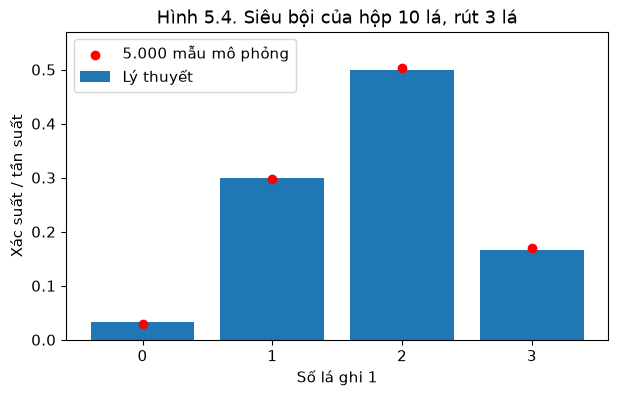

In [21]:
x_hg = np.arange(4)
p_hg = stats.hypergeom.pmf(x_hg, M=10, n=6, N=3)
p_hg_tay = np.array([comb(6, k) * comb(4, 3-k) / comb(10, 3) for k in x_hg])
assert np.allclose(p_hg, p_hg_tay)
hop01 = np.array([1]*6 + [0]*4)
ket_qua_hg = []
for i in range(5000):
    lan_rut = rng.choice(hop01, size=3, replace=False)
    ket_qua_hg.append(lan_rut.sum())
ket_qua_hg = np.array(ket_qua_hg)
ts_hg = np.array([(ket_qua_hg == k).mean() for k in x_hg])
print('Tần suất X=2:', round((ket_qua_hg == 2).mean(), 4))
print('Xác suất X=2:', stats.hypergeom.pmf(2, M=10, n=6, N=3))
display(pd.DataFrame({'k': x_hg, 'PMF tính tay': p_hg_tay, 'SciPy': p_hg, 'Tần suất': ts_hg}))
fig, ax = plt.subplots()
ax.bar(x_hg, p_hg, width=0.8, label='Lý thuyết')
ax.scatter(x_hg, ts_hg, color='red', label='5.000 mẫu mô phỏng')
ax.set(xticks=x_hg, ylim=(0, 0.57), xlabel='Số lá ghi 1', ylabel='Xác suất / tần suất',
       title='Hình 5.4. Siêu bội của hộp 10 lá, rút 3 lá')
ax.legend()
plt.show()

`replace=False` chỉ áp dụng **trong mỗi bộ ba lá**. Lần lặp kế tiếp bắt đầu với đủ hộp 10 lá; ta không tiếp tục bỏ những lá đã rút ở lần lặp trước. Tổng ba giá trị 0/1 bằng số lá 1. Tần suất dao động quanh 0,5; slide seed 214 ghi 0,5004, còn notebook dùng seed 42.

### Ví dụ 15 — Mười lăm bài dự án đầu tiên

Giảng viên dạy hai lớp, gồm 20 và 30 sinh viên. Mỗi sinh viên nộp một bài dự án. Xáo ngẫu nhiên 50 bài rồi chấm 15 bài đầu; mọi thứ tự có cùng khả năng. Gọi $X$ là số bài của **lớp thứ hai** trong 15 bài đầu.

1. Tính xác suất có đúng 10 bài lớp thứ hai.
2. Tính xác suất ít nhất 10 trong 15 bài thuộc **cùng một lớp**.

Câu 2 không chỉ hỏi lớp thứ hai. Viết hai khả năng: lớp thứ hai có ít nhất 10 bài, hoặc lớp thứ nhất có ít nhất 10 bài.

<details><summary>Đáp án và cách lập luận</summary><div><p>$X\sim\operatorname{Hypergeometric}(50,30,15)$.</p> <p>$$P(X=10)=\frac{\binom{30}{10}\binom{20}{5}}{\binom{50}{15}}\approx0{,}2070.$$</p> <p>Lớp thứ nhất có $15-X$ bài. “Ít nhất 10 bài cùng lớp” nghĩa là $X\geq10$ hoặc $15-X\geq10$, tức $X\geq10$ hoặc $X\leq5$. Hai miền xung khắc, nên</p> <p>$$P(X\geq10\text{ hoặc }X\leq5)=\sum_{k=10}^{15}p_X(k)+\sum_{k=0}^{5}p_X(k)\approx0{,}3938.$$</p> <p>Việc xáo ngẫu nhiên tạo một mẫu không hoàn lại; nó không tạo 15 lượt độc lập. Xác suất 0,3938 mô tả biến cố cả hai loại lớp, không phải xác suất lớp thứ hai chiếm ít nhất 10 bài.</p> </div></details>

In [22]:
rv_bai = stats.hypergeom(M=50, n=30, N=15)
print('Đúng 10 bài lớp thứ hai:', round(rv_bai.pmf(10), 4))
print('Ít nhất 10 bài cùng một lớp:', round(rv_bai.sf(9) + rv_bai.cdf(5), 4))
print('Hai phần xung khắc:', round(rv_bai.sf(9), 4), 'và', round(rv_bai.cdf(5), 4))

Đúng 10 bài lớp thứ hai: 0.207
Ít nhất 10 bài cùng một lớp: 0.3938
Hai phần xung khắc: 0.3798 và 0.014


`sf(9)` lấy $X\geq10$; `cdf(5)` lấy $X\leq5$. Tổng được phép vì không có giá trị $X$ nào vừa ít nhất 10 vừa không quá 5.

### Ví dụ 16 — Có và không hoàn lại từ hộp bốn bóng

Hộp có hai bóng đỏ và hai bóng xanh. Rút ngẫu nhiên ba lần, mỗi lần mọi bóng còn trong hộp cùng khả năng được lấy. So sánh **có hoàn lại** và **không hoàn lại**. $X$ là số bóng đỏ được rút.

1. Xác định các giá trị của $X$ và lập phân phối trong từng cách rút.
2. Tính $P(X=3)$ và $P(X=2)$ cho từng cách.
3. Giải thích vì sao hai phân phối khác nhau.

Hãy nghĩ đến giới hạn vật lý: hộp chỉ có hai bóng đỏ. Có thể rút được ba lượt đỏ khi đặt bóng trở lại, còn ba bóng đỏ phân biệt không tồn tại trong hộp.

<details><summary>Đáp án và cách lập luận</summary><div><p>Có hoàn lại: các lần độc lập, xác suất đỏ luôn $1/2$, nên $X\sim\operatorname{Binomial}(3,1/2)$, nhận $0,1,2,3$.</p> <p>Không hoàn lại: $X\sim\operatorname{Hypergeometric}(4,2,3)$. Vì lấy ba trong bốn bóng mà mỗi màu chỉ có hai, mẫu phải có cả hai màu; $X$ chỉ nhận 1 hoặc 2.</p> <table> <thead> <tr>   <th>$x$</th>   <th style="text-align:right">0</th>   <th style="text-align:right">1</th>   <th style="text-align:right">2</th>   <th style="text-align:right">3</th> </tr> </thead> <tbody> <tr>   <td>Có hoàn lại</td>   <td style="text-align:right">$1/8$</td>   <td style="text-align:right">$3/8$</td>   <td style="text-align:right">$3/8$</td>   <td style="text-align:right">$1/8$</td> </tr> <tr>   <td>Không hoàn lại</td>   <td style="text-align:right">0</td>   <td style="text-align:right">$1/2$</td>   <td style="text-align:right">$1/2$</td>   <td style="text-align:right">0</td> </tr> </tbody> </table> <p>$P(X=3)$ lần lượt là $1/8$ và 0; $P(X=2)$ lần lượt là $3/8$ và $1/2$. Khi không hoàn lại, sau lần đầu đỏ, xác suất đỏ lần tiếp theo là $1/3$; sau lần đầu xanh, xác suất đỏ lần tiếp theo là $2/3$. Thành phần hộp thay đổi tạo phụ thuộc giữa các lần rút.</p> </div></details>

,x,Có hoàn lại,Không hoàn lại
0,0,0.125,0.0
1,1,0.375,0.5
2,2,0.375,0.5
3,3,0.125,0.0


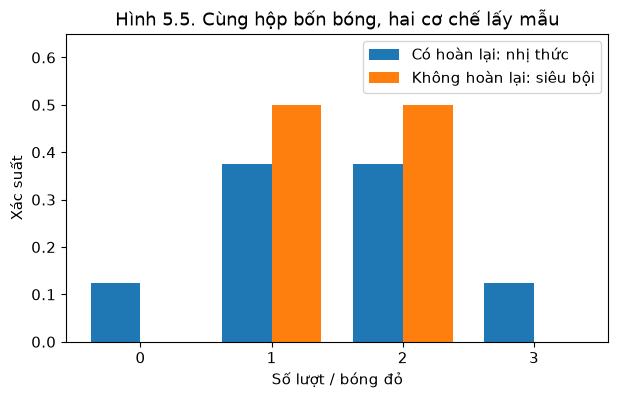

In [23]:
k_bong = np.arange(4)
p_bong_co = stats.binom.pmf(k_bong, n=3, p=0.5)
p_bong_khong = stats.hypergeom.pmf(k_bong, M=4, n=2, N=3)
display(pd.DataFrame({'x': k_bong, 'Có hoàn lại': p_bong_co, 'Không hoàn lại': p_bong_khong}))
fig, ax = plt.subplots()
ax.bar(k_bong - 0.19, p_bong_co, width=0.38, label='Có hoàn lại: nhị thức')
ax.bar(k_bong + 0.19, p_bong_khong, width=0.38, label='Không hoàn lại: siêu bội')
ax.set(xticks=k_bong, ylim=(0, 0.65), xlabel='Số lượt / bóng đỏ', ylabel='Xác suất',
       title='Hình 5.5. Cùng hộp bốn bóng, hai cơ chế lấy mẫu')
ax.legend()
plt.show()

Nhị thức và siêu bội đều đếm thành công trong số lượt cố định, nhưng cơ chế lấy mẫu khác nhau. Khi cỡ mẫu rất nhỏ so với hộp, loại vài lá thường làm xác suất thay đổi ít; nhị thức với $p=K/N$ có thể **xấp xỉ** siêu bội. Nó không biến rút không hoàn lại thành độc lập chính xác.

Ô bổ sung theo STAT 20 §4.3.2.6 kiểm tra cùng $n=10$, $K/N=1/2$ khi hộp có 20, 100, 1.000 lá. Quan sát xác suất không có thành công và khoảng cách lớn nhất giữa hai PMF. Ví dụ nguồn dùng $N=1000,K=500,n=10$, cho xác suất không thành công khoảng 0,0009 bằng siêu bội và 0,0009765625 bằng nhị thức.

In [24]:
k_so_sanh = np.arange(11)
p_bin_10 = stats.binom.pmf(k_so_sanh, n=10, p=0.5)
so_sanh_xap_xi = []
for N_hop in [20, 100, 1000]:
    p_sieu_boi = stats.hypergeom.pmf(k_so_sanh, M=N_hop, n=N_hop//2, N=10)
    so_sanh_xap_xi.append({'N': N_hop, 'n/N': 10/N_hop,
        'P_HG(X=0)': p_sieu_boi[0], 'P_Bin(X=0)': p_bin_10[0],
        'Sai khác PMF lớn nhất': np.max(np.abs(p_sieu_boi-p_bin_10))})
display(pd.DataFrame(so_sanh_xap_xi))

,N,n/N,P_HG(X=0),P_Bin(X=0),Sai khác PMF lớn nhất
0,20,0.50,0.000005,0.000977,0.097624
1,100,0.10,0.000593,0.000977,0.013240
2,1000,0.01,0.000933,0.000977,0.001239


Với cùng cỡ mẫu và cùng tỉ lệ thành công, tăng kích thước hộp làm hai PMF gần nhau hơn trong minh họa này. Điều cần biện minh là mức sai lệch xấp xỉ có phù hợp với câu hỏi đang giải không; tên “nhị thức” không thể thay thế mô tả cơ chế chọn mẫu.

## 6. Poisson: đếm sự kiện trong khoảng quan sát cố định

Số yêu cầu máy chủ trong một giây không có một số phép thử $n$ cố định dễ thấy như bài trắc nghiệm. **Phân phối Poisson** mô tả số sự kiện trong một khoảng quan sát với tham số $\lambda>0$:

$$X\sim\operatorname{Poisson}(\lambda),\qquad P(X=k)=\frac{e^{-\lambda}\lambda^k}{k!},\quad k=0,1,2,\ldots.$$

$k$ là số sự kiện; $e$ là hằng số Euler; $k!$ là giai thừa; $\lambda$ là số sự kiện trung bình **trong cả khoảng đang đếm**. Các giá trị có thể nhận là mọi số nguyên không âm, không có cận trên hữu hạn.

Khi áp dụng mô hình đếm theo thời gian, ta giả sử tốc độ trung bình ổn định, số sự kiện ở những khoảng không giao nhau độc lập, và trong một khoảng rất ngắn xác suất nhiều sự kiện cùng xảy ra là rất nhỏ. Có những hệ thống không phù hợp: yêu cầu tới thành đợt sau một thông báo lớn, hay tốc độ thay đổi nhiều giữa giờ cao điểm và thấp điểm.

Nếu tốc độ là $r$ sự kiện/giây và quan sát $t$ giây, tham số đếm là $\lambda=rt$. Đơn vị của khoảng thời gian phải khớp với đơn vị tốc độ. Không tự thay $\lambda=4$ vào bài đếm ba giây chỉ vì tốc độ bằng 4 mỗi giây.

### Ví dụ 17 — Poisson với tham số 1

$X$ là số sự kiện trong một khoảng cố định, $X\sim\operatorname{Poisson}(1)$. Tính xác suất sự kiện xảy ra **đúng một lần** và **không quá một lần**.

Đúng một lần là một khối PMF; không quá một lần gồm 0 và 1. Công thức không cần giả định rằng “ít nhất một lần” chắc chắn sẽ xảy ra.

<details><summary>Đáp án và cách lập luận</summary><div><p>$$P(X=1)=\frac{e^{-1}1^1}{1!}=e^{-1}\approx0{,}3679.$$</p> <p>Vì $P(X=0)=e^{-1}1^0/0!=e^{-1}$,</p> <p>$$P(X\leq1)=P(X=0)+P(X=1)=2e^{-1}\approx0{,}7358.$$</p> <p>Vậy một khoảng có đúng một sự kiện với xác suất khoảng 36,79%; không quá một sự kiện với xác suất khoảng 73,58%. “Không quá một” vẫn bao gồm khoảng không có sự kiện nào.</p> </div></details>

P(X=1): 0.3679
P(X≤1): 0.7358
Khối xác suất còn ngoài hình, P(X>8): 1.1252025979690174e-06


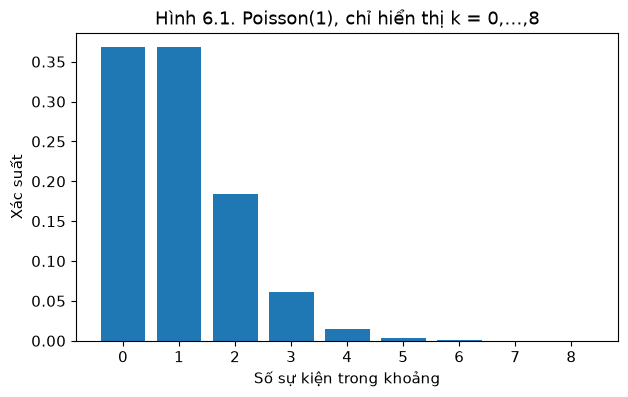

In [25]:
k_pois = np.arange(9)
p_pois = stats.poisson.pmf(k_pois, mu=1)
print('P(X=1):', round(stats.poisson.pmf(1, mu=1), 4))
print('P(X≤1):', round(stats.poisson.cdf(1, mu=1), 4))
print('Khối xác suất còn ngoài hình, P(X>8):', stats.poisson.sf(8, mu=1))
fig, ax = plt.subplots()
ax.bar(k_pois, p_pois, width=0.8)
ax.set(xticks=k_pois, xlabel='Số sự kiện trong khoảng', ylabel='Xác suất',
       title='Hình 6.1. Poisson(1), chỉ hiển thị k = 0,…,8')
plt.show()
assert np.isclose(p_pois[0], p_pois[1])

Hai cột 0 và 1 có cùng chiều cao $e^{-1}$. Hình chỉ vẽ từ 0 tới 8 để dễ nhìn; không có nghĩa là $X$ không thể vượt 8. Tổng các cột hiển thị nhỏ hơn 1 một lượng bằng xác suất đuôi mà ô trên in ra. Đừng chuẩn hóa lại các cột để biến phần hiển thị thành cả phân phối.

### Ví dụ 18 — Máy chủ nhận yêu cầu

Máy chủ nhận trung bình 4 yêu cầu/giây. Giả sử yêu cầu đến theo mô hình Poisson với tốc độ ổn định; số yêu cầu trong các khoảng không giao nhau độc lập. Đặt $X$ là số yêu cầu trong một giây.

1. Tính xác suất không có yêu cầu.
2. Tính xác suất có nhiều hơn 6 yêu cầu.
3. Xác định phân phối số yêu cầu trong 3 giây.

Trước khi tính, ghi đơn vị của tốc độ và độ dài khoảng; câu 3 đếm ba giây thay vì một giây.

<details><summary>Đáp án và cách lập luận</summary><div><p>$X\sim\operatorname{Poisson}(4)$.</p> <p>$$P(X=0)=e^{-4}\approx0{,}0183.$$</p> <p>$$P(X&gt;6)=1-\sum_{k=0}^{6}\frac{e^{-4}4^k}{k!}\approx0{,}1107.$$</p> <p>Trong ba giây, $\lambda=3\cdot4=12$, nên số yêu cầu có phân phối $\operatorname{Poisson}(12)$. Xác suất vượt 6 yêu cầu trong <strong>một giây</strong> khoảng 11,07%; con số này không áp dụng nguyên trạng cho khoảng ba giây.</p> </div></details>

In [26]:
print('Không có yêu cầu trong 1 giây:', round(stats.poisson.pmf(0, mu=4), 4))
print('Hơn 6 yêu cầu trong 1 giây:', round(stats.poisson.sf(6, mu=4), 4))
toc_do = 4  # yêu cầu / giây
thoi_gian = 3  # giây; thử đổi thành 1 hoặc 5
lam = toc_do * thoi_gian
print(f'Khoảng {thoi_gian} giây: Poisson({lam}), P(0 yêu cầu) = {stats.poisson.pmf(0, mu=lam):.6f}')

Không có yêu cầu trong 1 giây: 0.0183
Hơn 6 yêu cầu trong 1 giây: 0.1107
Khoảng 3 giây: Poisson(12), P(0 yêu cầu) = 0.000006


Đổi `thoi_gian` làm đổi $\lambda$ theo đúng độ dài khoảng. Chỉ biết tốc độ trung bình chưa đủ kết luận phân phối là Poisson; giả định ổn định và độc lập giữa khoảng vẫn cần đáp ứng.

Một liên hệ bổ sung trong STAT 20 §4.3.2.5: nếu có rất nhiều phép thử Bernoulli độc lập, mỗi phép có xác suất nhỏ, thì $\operatorname{Binomial}(n,p)$ có thể gần $\operatorname{Poisson}(\lambda)$ với $\lambda=np$. Ô dưới giữ $np=4$, tăng $n$ và giảm $p$ để so sánh xác suất. Đây là xấp xỉ rời rạc, không phải xấp xỉ chuẩn của Tuần 07.

In [27]:
k_rare = np.arange(16)
rows_rare = []
for n_rare in [20, 100, 1000]:
    p_rare = 4 / n_rare
    probs_bin = stats.binom.pmf(k_rare, n=n_rare, p=p_rare)
    probs_pois = stats.poisson.pmf(k_rare, mu=4)
    rows_rare.append({'n': n_rare, 'p': p_rare, 'np': n_rare*p_rare,
        'P_Bin(X>6)': stats.binom.sf(6, n=n_rare, p=p_rare),
        'P_Pois(X>6)': stats.poisson.sf(6, mu=4),
        'Sai khác PMF lớn nhất trong k=0…15': np.max(np.abs(probs_bin-probs_pois))})
display(pd.DataFrame(rows_rare))

,n,p,np,P_Bin(X>6),P_Pois(X>6),Sai khác PMF lớn nhất trong k=0…15
0,20,0.200,4.0,0.086693,0.110674,0.022833
1,100,0.040,4.0,0.106392,0.110674,0.004022
2,1000,0.004,4.0,0.110256,0.110674,0.000392


Giữ $np=4$ và làm $p$ nhỏ hơn cho hai mô hình gần nhau trong những xác suất đang kiểm tra. Nhị thức vẫn có cận trên $n$, còn Poisson không có; xấp xỉ không làm hai phân phối bằng nhau. Nếu các lần thử phụ thuộc hoặc xác suất thay đổi, không thể chỉ dựa vào tích $np$ để biện minh mô hình.

## 7. Dịch câu hỏi thành xác suất và chọn mô hình

### Bảng tra thao tác SciPy

Với biến nguyên $X$, các dấu trong câu hỏi quyết định hàm cần gọi:

| Câu hỏi | Công thức | Lệnh trên một phân phối `rv` |
|---|---|---|
| Đúng $k$ | $P(X=k)$ | `rv.pmf(k)` |
| Không quá $k$ | $P(X\leq k)$ | `rv.cdf(k)` |
| Ít hơn $k$ | $P(X\leq k-1)$ | `rv.cdf(k-1)` |
| Nhiều hơn $k$ | $P(X>k)$ | `rv.sf(k)` |
| Ít nhất $k$ | $P(X>k-1)$ | `rv.sf(k-1)` |
| Từ $a$ đến $b$, gồm hai đầu nguyên | $F_X(b)-F_X(a-1)$ | `rv.cdf(b)-rv.cdf(a-1)` |

`sf` là survival function, bằng $1-\mathrm{cdf}$ về mặt toán học; SciPy tính trực tiếp để tránh mất độ chính xác khi xác suất đuôi nhỏ. Bảng này dành cho biến nhận giá trị nguyên. Với tập giá trị rời rạc không nguyên, cần xác định đúng điểm trước cận, hoặc cộng các khối phù hợp.

Ô sau giữ bốn phép tính của slide trang 68–69. Phép siêu bội cuối dùng một hộp **30 linh kiện, 6 lỗi, lấy 5 không hoàn lại**; khác hộp 10 lá của Ví dụ 14.

In [28]:
p_dung_11 = stats.binom.pmf(11, n=12, p=0.95)
p_it_nhat_11 = stats.binom.sf(10, n=12, p=0.95)
p_qua_6 = stats.poisson.sf(6, mu=4)
p_dung_2 = stats.hypergeom.pmf(2, M=30, n=6, N=5)
for ten, p in [('Đúng 11 sản phẩm đạt', p_dung_11),
               ('Ít nhất 11 sản phẩm đạt', p_it_nhat_11),
               ('Hơn 6 yêu cầu', p_qua_6),
               ('Đúng 2 lỗi từ 5 linh kiện', p_dung_2)]:
    print(f'{ten}: {p:.4f}')

Đúng 11 sản phẩm đạt: 0.3413
Ít nhất 11 sản phẩm đạt: 0.8816
Hơn 6 yêu cầu: 0.1107
Đúng 2 lỗi từ 5 linh kiện: 0.2130


Các kết quả lần lượt là 0,3413; 0,8816; 0,1107; 0,2130. Mỗi kết quả chỉ có ý nghĩa cùng với biến được đếm và điều kiện mô hình. Tham số `mu` của Poisson là $\lambda$; ba đối số siêu bội của SciPy phải được gắn đúng với kích thước hộp, số thành công và cỡ mẫu.

### Ví dụ 19 — Ghép tình huống với mô hình

Ghép từng tình huống với Bernoulli, nhị thức, siêu bội hoặc Poisson. Nêu điều kiện cần để mô hình hợp lý.

1. Một gói hàng có đến đúng hạn hay không.
2. Số gói đến đúng hạn trong 20 gói độc lập.
3. Số cuộc gọi tới tổng đài trong 10 phút.
4. Số sinh viên thuận tay trái trong 20 sinh viên lấy ngẫu nhiên không hoàn lại từ một khoa có 180 sinh viên.

Tên mô hình phải đi cùng cách thử. Với tình huống 4, liệu biết 180 và 20 đã đủ tính xác suất cụ thể chưa?

<details><summary>Đáp án và cách lập luận</summary><div><ol> <li><strong>Bernoulli:</strong> mã hóa đúng hạn bằng 1 và không đúng hạn bằng 0, tham số là xác suất đúng hạn.</li> <li><strong>Nhị thức:</strong> $n=20$, nếu kết quả các gói độc lập và cùng xác suất đúng hạn $p$. Độc lập được đề cho, còn tính không đổi của $p$ vẫn cần nêu.</li> <li><strong>Poisson:</strong> tham số là số cuộc gọi trung bình trong 10 phút, nếu tốc độ ổn định và số cuộc gọi ở những khoảng không giao nhau độc lập theo mô hình.</li> <li><strong>Siêu bội:</strong> $N=180,n=20$, vì mẫu ngẫu nhiên không hoàn lại từ tổng thể hữu hạn. Cần biết thêm $K$, số sinh viên thuận tay trái trong khoa, để tính PMF cụ thể.</li> </ol> <p>Có thể xác định một họ mô hình mà chưa có đủ tham số để tính số. Mỗi mô hình chỉ phù hợp khi các điều kiện đi kèm được đáp ứng đủ gần với thực tế.</p> </div></details>

## 8. Hai bài toán tổng hợp

### Ví dụ 20 — Cảnh báo giả của cảm biến

Hệ thống có 8 cảm biến hoạt động độc lập. Trong một ca, mỗi cảm biến phát cảnh báo giả với xác suất 0,04.

1. Lập phân phối của số cảnh báo giả $X$.
2. Tính xác suất có ít nhất một cảnh báo giả.

Hãy dự đoán trước: xác suất toàn hệ thống có cảnh báo giả có bằng 0,04 không? Số 0,04 mô tả một cảm biến, còn hệ thống có tám cơ hội phát cảnh báo.

<details><summary>Đáp án và cách lập luận</summary><div><p>$X\sim\operatorname{Binomial}(8,0{,}04)$ và</p> <p>$$P(X=k)=\binom8k(0{,}04)^k(0{,}96)^{8-k},\qquad k=0,\ldots,8.$$</p> <p>Ít nhất một cảnh báo là phần bù của không cảm biến nào báo:</p> <p>$$P(X\geq1)=1-P(X=0)=1-(0{,}96)^8\approx0{,}2786\approx0{,}279.$$</p> <p>Theo mô hình độc lập, hệ thống có ít nhất một cảnh báo giả trong ca với xác suất khoảng 27,86%. Không cộng đơn giản $8\cdot0{,}04$, vì các biến cố cảnh báo của các cảm biến không xung khắc: nhiều cảm biến có thể cùng báo.</p> </div></details>

In [29]:
k_cam_bien = np.arange(9)
p_cam_bien = stats.binom.pmf(k_cam_bien, n=8, p=0.04)
display(pd.DataFrame({'Số cảnh báo giả': k_cam_bien, 'PMF': p_cam_bien}))
print('P(ít nhất 1) = 1-0.96^8 =', round(1-0.96**8, 4))
print('Kiểm tra sf(0):', round(stats.binom.sf(0, n=8, p=0.04), 4))
assert np.isclose(1-0.96**8, stats.binom.sf(0, n=8, p=0.04))

,Số cảnh báo giả,PMF
0,0,7.213896e-01
1,1,2.404632e-01
2,2,3.506755e-02
3,3,2.922296e-03
4,4,1.522029e-04
5,5,5.073430e-06
6,6,1.056965e-07
7,7,1.258291e-09
8,8,6.553600e-12


P(ít nhất 1) = 1-0.96^8 = 0.2786
Kiểm tra sf(0): 0.2786


Nếu một nguồn nhiễu chung làm nhiều cảm biến cùng báo, điều kiện độc lập có thể sai. Khi đó không nên giữ nguyên tính toán $0{,}96^8$ chỉ vì mỗi cảm biến vẫn có xác suất báo 0,04. Điều kiện mô hình quyết định cách kết hợp các xác suất.

### Ví dụ 21 — Tồn kho hai loại bộ mở cửa garage

Cửa hàng bán loại truyền động xích và loại truyền động trục. Mỗi khách mua một bộ, các lựa chọn độc lập. Xác suất chọn xích là 0,75 và chọn trục là 0,25. Tồn kho gồm 10 bộ xích và 8 bộ trục. Xét 15 khách tiếp theo, không nhập thêm hàng, và khách không đổi sang loại khác khi hết hàng.

1. Lập phân phối của $X$, số khách chọn loại xích.
2. Tính xác suất đáp ứng được cả 15 khách bằng lượng hàng hiện có.

Có 18 bộ cho 15 khách nhưng chưa biết có đủ **đúng loại** không. Viết riêng hai điều kiện tồn kho, rồi tìm phần giao của chúng.

<details><summary>Đáp án và cách lập luận</summary><div><p>Các lựa chọn vẫn độc lập với xác suất 0,75 như đề bài, nên $X\sim\operatorname{Binomial}(15,0{,}75)$, với</p> <p>$$P(X=k)=\binom{15}k(0{,}75)^k(0{,}25)^{15-k},\quad k=0,\ldots,15.$$</p> <p>Đáp ứng cả 15 khách cần đồng thời $X\leq10$ (đủ xích) và $15-X\leq8$ (đủ trục). Điều kiện thứ hai cho $X\geq7$. Vì vậy:</p> <p>$$A=\{7\leq X\leq10\},\qquad P(A)=\sum_{k=7}^{10}\binom{15}k(0{,}75)^k(0{,}25)^{15-k}\approx0{,}3093.$$</p> <p>Xác suất phục vụ đủ khoảng 30,93%. Tổng hàng lớn hơn tổng khách chưa bảo đảm loại hàng phù hợp. Việc tồn kho giảm không làm <strong>lựa chọn của khách</strong> trở thành siêu bội, vì đề đã giả sử khách không đổi loại khi hết hàng. Ta đang đếm nhu cầu, không rút ngẫu nhiên những bộ có sẵn từ kho.</p> </div></details>

Miền đủ hàng: [ 7  8  9 10]
Tính bằng tổng PMF: 0.3093
Tính bằng F(10)-F(6): 0.3093


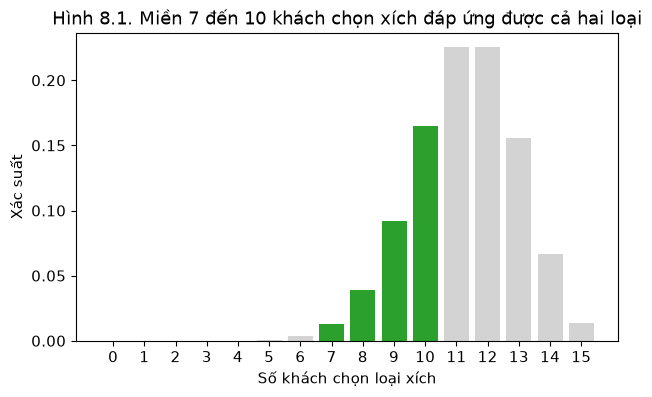

In [30]:
k_kho = np.arange(16)
p_kho = stats.binom.pmf(k_kho, n=15, p=0.75)
du_hang = (k_kho <= 10) & (15-k_kho <= 8)
p_du_hang_tay = p_kho[du_hang].sum()
p_du_hang_cdf = stats.binom.cdf(10, n=15, p=0.75) - stats.binom.cdf(6, n=15, p=0.75)
print('Miền đủ hàng:', k_kho[du_hang])
print('Tính bằng tổng PMF:', round(p_du_hang_tay, 4))
print('Tính bằng F(10)-F(6):', round(p_du_hang_cdf, 4))
assert np.isclose(p_du_hang_tay, p_du_hang_cdf)
fig, ax = plt.subplots()
ax.bar(k_kho, p_kho, color=np.where(du_hang, 'tab:green', 'lightgray'))
ax.set(xticks=k_kho, xlabel='Số khách chọn loại xích', ylabel='Xác suất',
       title='Hình 8.1. Miền 7 đến 10 khách chọn xích đáp ứng được cả hai loại')
plt.show()

Các cột xanh cộng thành xác suất đáp ứng đủ. Thử đổi tồn kho xích và trục trong biểu thức `du_hang`, dự đoán miền đủ hàng trước khi chạy lại. Nếu số hàng một loại tăng, miền nhu cầu được chấp nhận có thể rộng hơn; phân phối **nhu cầu của khách** vẫn giữ nguyên khi các giả định lựa chọn không đổi.

## 9. Đối chiếu thêm các đồ thị của STAT 20 — bổ sung

Các hình sau vẽ lại những minh họa trong bản HTML ở đúng các mục phân phối rời rạc. Chúng dùng những khái niệm đã học; không thêm mô hình mới hay bài tập ngoài slide.

### Ba lần tung xu với xác suất ngửa 2/3

STAT 20 §3.4.3.3 minh họa một đồng xu lệch. Khi ba lần tung độc lập có $P(H)=2/3$, mỗi chuỗi có $k$ ngửa mang xác suất $(2/3)^k(1/3)^{3-k}$. Các chuỗi cùng số ngửa có cùng xác suất, nhưng tám chuỗi không còn đồng khả năng. Số ngửa có PMF tại $0,1,2,3$ là $1/27,6/27,12/27,8/27$.

Hình 9.1 tái dựng cột PMF của hình viết tay trong nguồn. Đúng hai mặt ngửa có nhiều xác suất nhất, vì có ba cách đặt hai mặt ngửa và mỗi chuỗi mang xác suất $4/27$.

,Kết quả ω,X = số ngửa,Xác suất của chuỗi
0,HHH,3,0.296296
1,HHT,2,0.148148
2,HTH,2,0.148148
3,HTT,1,0.074074
4,THH,2,0.148148
5,THT,1,0.074074
6,TTH,1,0.074074
7,TTT,0,0.037037


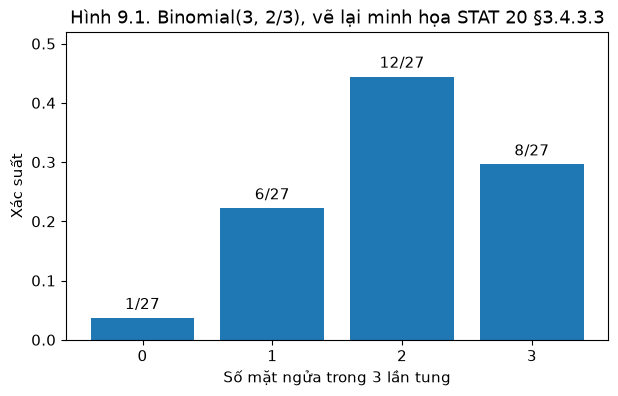

In [31]:
p_xu_lech = stats.binom.pmf(np.arange(4), n=3, p=2/3)
bang_xu_lech = bang_xu[['Kết quả ω', 'X = số ngửa']].copy()
bang_xu_lech['Xác suất của chuỗi'] = (2/3)**bang_xu_lech['X = số ngửa'] * (1/3)**(3-bang_xu_lech['X = số ngửa'])
display(bang_xu_lech)
fig, ax = plt.subplots()
ax.bar(np.arange(4), p_xu_lech, width=0.8)
for x, tu_so in zip(range(4), [1, 6, 12, 8]):
    ax.text(x, tu_so/27 + 0.015, f'{tu_so}/27', ha='center')
ax.set(xticks=range(4), ylim=(0, 0.52), xlabel='Số mặt ngửa trong 3 lần tung', ylabel='Xác suất',
       title='Hình 9.1. Binomial(3, 2/3), vẽ lại minh họa STAT 20 §3.4.3.3')
plt.show()

### Tổng hai xúc xắc khi chỉ mô phỏng 50 lần

STAT 20 §3.4.4.4–3.4.4.5 đặt biểu đồ lý thuyết bên cạnh tần suất của 50 lần gieo. Mẫu nhỏ có thể trông lệch nhiều dù cơ chế vẫn là hai xúc xắc cân đối độc lập. Bảng lý thuyết giữ nguyên $1,2,3,4,5,6,5,4,3,2,1$ chia 36; hình thực nghiệm dùng **50 kết quả đầu của mô phỏng Ví dụ 2**, vì vậy khác mẫu R trong nguồn.

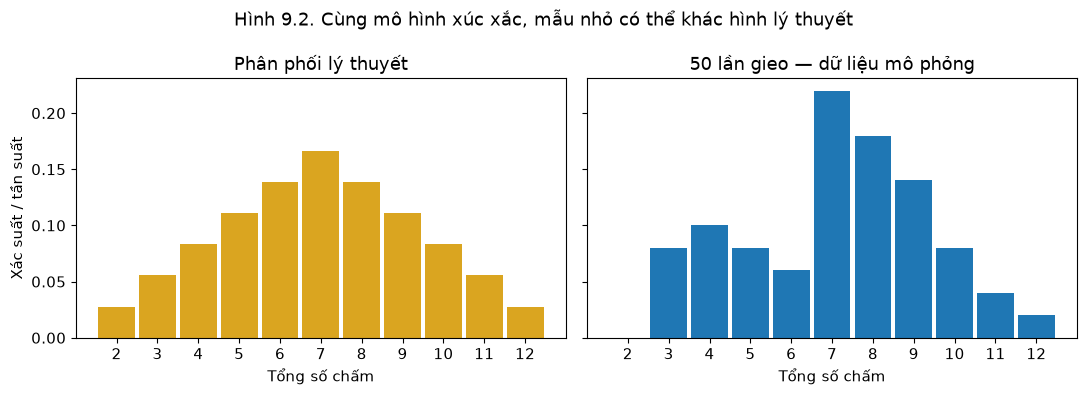

In [32]:
f_dice_50 = np.array([(tong_dice[:50] == k).mean() for k in x_dice])
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
axes[0].bar(x_dice, p_dice, width=0.9, color='goldenrod')
axes[1].bar(x_dice, f_dice_50, width=0.9, color='tab:blue')
for ax, ten in zip(axes, ['Phân phối lý thuyết', '50 lần gieo — dữ liệu mô phỏng']):
    ax.set(xticks=x_dice, xlabel='Tổng số chấm', title=ten)
axes[0].set_ylabel('Xác suất / tần suất')
fig.suptitle('Hình 9.2. Cùng mô hình xúc xắc, mẫu nhỏ có thể khác hình lý thuyết')
fig.tight_layout()
plt.show()

Mỗi cột ở hình phải tăng theo bội số $1/50=0{,}02$. Việc mẫu này có nhiều tổng 7 hay một tổng bị thiếu không đổi xác suất của lần gieo sau. Hai hình cùng thang đo để không tạo cảm giác hai chiều cao khác nhau chỉ do trục tung.

### Một histogram sự kiện hiếm có dạng giống ví dụ quân đội Phổ

STAT 20 §4.3.2.5, Figure 8 dùng dữ liệu tử vong do ngựa đá trong 14 trung đoàn qua 20 năm để minh họa dạng lệch phải. Bản HTML cung cấp đồ thị, không cung cấp bảng 280 quan sát để chạy lại. Vì vậy Hình 9.3 dùng **280 quan sát mô phỏng Poisson(0,7)** để minh họa cùng dạng: phần lớn khoảng có 0 hoặc 1 sự kiện và ít khoảng có nhiều sự kiện. Tham số 0,7 được chọn cho minh họa; đây không phải bảng dữ liệu lịch sử và không phải một ước lượng từ ảnh.

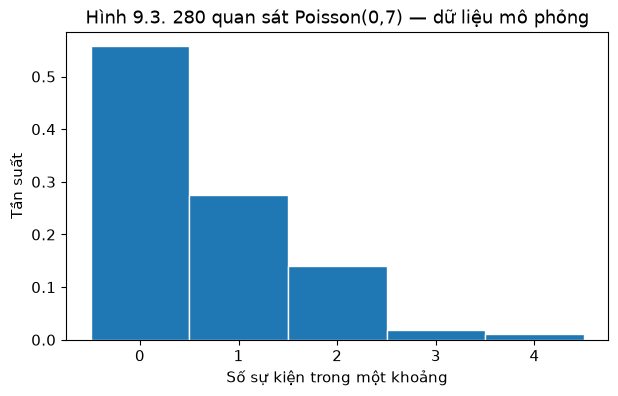

,Số sự kiện,Số khoảng,Tần suất
0,0,156,0.557143
1,1,77,0.275000
2,2,39,0.139286
3,3,5,0.017857
4,4,3,0.010714


In [33]:
su_kien_hiem = rng.poisson(lam=0.7, size=280)
k_hiem = np.arange(su_kien_hiem.max() + 1)
f_hiem = np.array([(su_kien_hiem == k).mean() for k in k_hiem])
fig, ax = plt.subplots()
ax.bar(k_hiem, f_hiem, width=1, edgecolor='white')
ax.set(xticks=k_hiem, xlabel='Số sự kiện trong một khoảng', ylabel='Tần suất',
       title='Hình 9.3. 280 quan sát Poisson(0,7) — dữ liệu mô phỏng')
plt.show()
display(pd.DataFrame({'Số sự kiện': k_hiem, 'Số khoảng': np.rint(280*f_hiem).astype(int), 'Tần suất': f_hiem}))

Histogram mô phỏng cho thấy vì sao Poisson phù hợp để khảo sát dạng phân phối của số sự kiện hiếm. Dạng hình gần giống không đủ chứng minh một bộ dữ liệu thật tuân theo Poisson: cần xem cơ chế, tính ổn định của tốc độ và sự phụ thuộc giữa các khoảng.

### Ba CDF được minh họa trong §4.4

Bản HTML dùng thêm ba bảng PMF: số ngửa trong ba lần tung xu cân đối; Bernoulli(0,5); và một biến nhận $-1,1,2,4$ với xác suất $0{,}2;0{,}3;0{,}4;0{,}1$. Ở bảng cuối, xác suất còn thiếu tại 4 được xác định bằng $1-(0{,}2+0{,}3+0{,}4)=0{,}1$.

CDF tương ứng tại các giá trị mang khối xác suất là $(1/8,1/2,7/8,1)$, $(1/2,1)$ và $(0{,}2,0{,}5,0{,}9,1)$. Giữa các điểm mang khối, CDF nằm ngang; trước điểm đầu là 0, từ điểm cuối trở đi là 1. Hình 9.4 vẽ lại ba đồ thị trong nguồn bằng Python, với chấm đặc ở đầu trên và vòng tròn rỗng ở giới hạn trái.

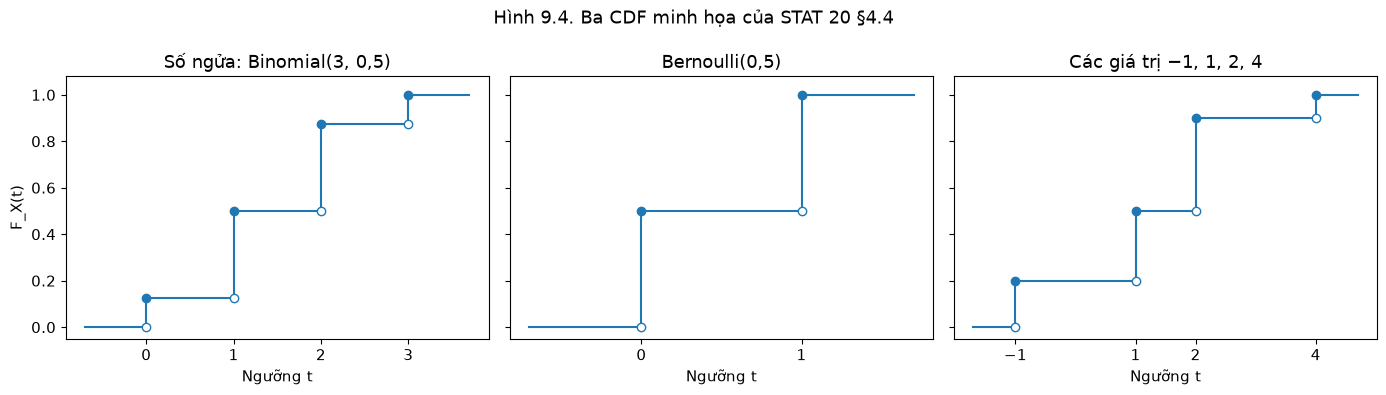

In [34]:
vi_du_cdf_stat20 = [
    (np.array([0, 1, 2, 3]), np.array([1, 3, 3, 1])/8, 'Số ngửa: Binomial(3, 0,5)'),
    (np.array([0, 1]), np.array([0.5, 0.5]), 'Bernoulli(0,5)'),
    (np.array([-1, 1, 2, 4]), np.array([0.2, 0.3, 0.4, 0.1]), 'Các giá trị −1, 1, 2, 4')]
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
for ax, (x_cdf, p_cdf, ten) in zip(axes, vi_du_cdf_stat20):
    F_cdf = p_cdf.cumsum()
    ax.step(np.r_[x_cdf[0]-0.7, x_cdf, x_cdf[-1]+0.7], np.r_[0, F_cdf, 1], where='post')
    ax.scatter(x_cdf, F_cdf, color='tab:blue', zorder=3)
    ax.scatter(x_cdf, np.r_[0, F_cdf[:-1]], facecolors='white', edgecolors='tab:blue', zorder=4)
    ax.set(xticks=x_cdf, ylim=(-0.05, 1.08), xlabel='Ngưỡng t', title=ten)
    assert np.isclose(p_cdf.sum(), 1)
axes[0].set_ylabel('F_X(t)')
fig.suptitle('Hình 9.4. Ba CDF minh họa của STAT 20 §4.4')
fig.tight_layout()
plt.show()

Tại $t=2$ của hình phải, CDF bằng 0,9; độ nhảy tại đó là $0{,}9-0{,}5=0{,}4$. Ở $t=0$, CDF vẫn là 0,2 dù 0 không phải giá trị có thể nhận của biến này. CDF được định nghĩa ở mọi số thực, còn PMF chỉ có khối dương tại các giá trị được bảng chỉ ra.

## 10. Những điều cần mang sang Tuần 07

Một phân phối xác suất mô tả mô hình trước khi quan sát; một biểu đồ tần suất thực nghiệm mô tả dữ liệu đã có. Mô phỏng làm hiện rõ dao động mẫu và kiểm tra phép tính, nhưng không tự chứng minh mô hình thực tế đúng.

Biến ngẫu nhiên gán số cho kết quả. PMF cho xác suất **đúng một giá trị**; CDF cộng mọi giá trị **không vượt ngưỡng**. Độ nhảy của CDF rời rạc là khối xác suất tại điểm nhảy; dấu ở các đầu khoảng quyết định khối nào được lấy.

Trước khi tính, chọn cơ chế: đều rời rạc khi các giá trị đồng khả năng; Bernoulli cho một kết quả 0/1; nhị thức cho số thành công trong số phép thử cố định độc lập với $p$ không đổi; siêu bội cho mẫu không hoàn lại từ hộp hữu hạn; Poisson cho số sự kiện trong một khoảng dưới giả định phù hợp.

Ở Tuần 07, ta dùng cùng bảng PMF để hỏi hai câu tiếp theo: **trung bình dài hạn của $X$ là bao nhiêu, và kết quả dao động quanh đó thế nào?** Đọc trước Kỳ vọng và phương sai, rồi Phân phối liên tục và xấp xỉ chuẩn trong STAT 20. Ôn việc lập PMF, tính xác suất bằng CDF và kiểm tra điều kiện mô hình trước khi đọc công thức kỳ vọng.

## Nguồn và bảng đối chiếu nội dung

Nguồn cấu trúc: **Đề cương UET.MAT1052**, Buổi 6, §3.4–3.5, LLO6.1. Nguồn nội dung và 21 ví dụ: **`Slides/week06.pdf`**, 80 trang. Nguồn bổ sung các mục đề cương chưa được slide trình bày đầy đủ: **`STAT20_in_Vietnamese.html`**, §3.4, §4.1–4.6. Mục đánh số 3.5 trong đề cương tương ứng phần biến ngẫu nhiên ở Chương 4 trong bản HTML.

| Nội dung trong notebook | Trang của slide | Nhãn gốc |
|---|---|---|
| Mục tiêu, tổng quan, nguồn | 1–5 | — |
| Hộp năm lá: PMF, tần suất 50/500/5.000 và hình so sánh | 6–12 | Ví dụ 1 |
| Hai xúc xắc, bảng đếm, mô phỏng và hình PMF | 13–15 | Ví dụ 2 |
| Định nghĩa $X:\Omega\to\mathbb R$, số ngửa | 16–18 | Ví dụ 3 |
| Rời rạc và liên tục | 19 | — |
| Phân phối, PMF, tính chất, số ngửa ba lần | 20–22 | Ví dụ 4 |
| Số ngửa trừ số sấp, đủ đề và đáp án | 23–24 | Ví dụ 5 |
| Định nghĩa/tính chất CDF, hai sản phẩm và hình bước nhảy | 25–30 | Ví dụ 6 |
| Xác suất từ CDF, dấu $<$ và độ nhảy | 31–32 | Ví dụ 7 |
| Sáu đường dây, bốn câu hỏi, CDF từng khoảng và đồ thị | 33–36 | Ví dụ 8 |
| Đều rời rạc, một xúc xắc và hình | 37–39 | Ví dụ 9 |
| Bernoulli, ba hình $p=1/2,3/4,2/3$ | 40–41 | Ví dụ 10 |
| Chia hết trong 1.000 số, biến chỉ báo | 42–43 | Ví dụ 11 |
| Nhị thức và bốn điều kiện; bài trắc nghiệm | 44–47 | Ví dụ 12 |
| Mười hai sản phẩm đạt chuẩn | 48–49 | Ví dụ 13 |
| Siêu bội, miền giá trị, hộp mười lá, đồ thị và mô phỏng | 50–54, 57–58 | Ví dụ 14; nhãn 57–58 được đính chính |
| Hai lớp, mười lăm bài dự án | 55–56 | Ví dụ 15 |
| Hộp bốn bóng, có/không hoàn lại | 59–60 | Ví dụ 16 |
| Poisson, tham số 1, xác suất và hình PMF | 61–64 | Ví dụ 17 |
| Máy chủ 4 yêu cầu/giây, đổi khoảng quan sát | 65–66 | Ví dụ 18 |
| Bốn lệnh SciPy, PMF/CDF/SF | 67–69 | — |
| Ghép mô hình và điều kiện | 70–71 | Ví dụ 19 |
| Tám cảm biến, cảnh báo giả | 72–74 | Ví dụ 20 |
| Tồn kho garage, miền đáp ứng cả hai loại | 75–77 | Ví dụ 21 |
| Tổng kết và chuẩn bị Tuần 07 | 78–80 | — |

**Phần bổ sung được chỉ rõ trong bài:** quy tắc đếm, chỉnh hợp/tổ hợp và ví dụ `CRATE`/bộ bài (§3.4.2); roulette và lãi ròng (§4.2); đối chiếu nhị thức–siêu bội khi hộp lớn (§4.3.2.6); Poisson xấp xỉ nhị thức với sự kiện hiếm (§4.3.2.5); các đồ thị tham khảo ở mục 9 được vẽ lại bằng Python (§3.4.3.3, §3.4.4.4–3.4.4.5, §4.3.2.5, §4.4). Các hoạt động thay đổi tham số và bảng tính Python phục vụ các ý đã có trong slide hoặc đề cương. Mục 9 không thêm bài tập ngoài slide.

**Hình minh họa gốc:** Hình 1.1, 2.1, 3.1, 3.3 được lấy từ bản HTML cục bộ và lưu trong `figures/`; notebook nhúng ảnh để khi chép riêng sang `Notebooks/` vẫn đọc được. Các biểu đồ xác suất/tần suất/CDF được vẽ lại bằng Python. Tất cả dữ liệu mô phỏng được ghi rõ; các bảng PMF tính từ công thức là giá trị lý thuyết.

**Điều chỉnh nguồn được ghi rõ:** slide trang 57–58 ghi “Ví dụ 15” nhưng mô phỏng hộp của Ví dụ 14; notebook sửa vị trí/nhãn, giữ nguyên nội dung tính toán. Các đầu ra mô phỏng dùng seed 42, khác seed 214 ở slide; các mẫu minh họa và số in trên slide vẫn được nêu để đối chiếu. Đáp án số học của các ví dụ giữ đúng công thức nguồn, làm tròn theo số chữ số đã ghi.